<a href="https://colab.research.google.com/github/minjaewls/Project_Runail/blob/main/Projecf_Runail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,138 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direc

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# NanumBarunGothic 폰트 경로를 찾거나 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = 'NanumBarunGothic'

# 폰트 매니저에 폰트 추가
try:
    # 폰트 파일이 존재하는지 확인
    if not os.path.exists(font_path):
        print(f"경로 '{font_path}'에서 '{font_name}.ttf' 폰트를 찾을 수 없습니다. 폰트 설치를 확인해주세요.")
    else:
        # 폰트 매니저에 폰트 추가 (rebuild() 호출 제거)
        fm.fontManager.addfont(font_path)
        print(f"'{font_path}' 폰트를 Matplotlib에 추가했습니다.")

        # 폰트가 실제로 등록되었는지 확인
        if font_name in [f.name for f in fm.fontManager.ttflist]:
            print(f"'{font_name}' 폰트가 Matplotlib 폰트 리스트에 성공적으로 등록되었습니다.")
        else:
            print(f"경고: '{font_name}' 폰트가 등록되었으나, fontManager 리스트에서 확인되지 않습니다.")

except Exception as e:
    print(f"폰트 설정 중 오류 발생: {e}")

# 폰트 설정 적용 (fallback 폰트 추가)
plt.rc('font', family=[font_name, 'sans-serif'])
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print(f"Matplotlib 폰트 설정이 완료되었습니다: '{font_name}'.")

# 현재 Matplotlib의 폰트 설정을 확인하여 문제 진단에 도움
print(f"현재 Matplotlib의 기본 폰트: {plt.rcParams['font.family']}")
print(f"현재 Matplotlib의 axes.unicode_minus 설정: {plt.rcParams['axes.unicode_minus']}")

'/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' 폰트를 Matplotlib에 추가했습니다.
'NanumBarunGothic' 폰트가 Matplotlib 폰트 리스트에 성공적으로 등록되었습니다.
Matplotlib 폰트 설정이 완료되었습니다: 'NanumBarunGothic'.
현재 Matplotlib의 기본 폰트: ['NanumBarunGothic', 'sans-serif']
현재 Matplotlib의 axes.unicode_minus 설정: False


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
#!/bin/bash
!kaggle datasets download mkechinov/ecommerce-events-history-in-cosmetics-shop

Dataset URL: https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop
License(s): copyright-authors
100% 430M/430M [00:04<00:00, 97.5MB/s]



In [ ]:
!unzip -q ecommerce-events-history-in-cosmetics-shop.zip -d ./looker_data

In [ ]:
import sqlite3
import pandas as pd
import os

# 1. 데이터 로드 (메모리 초기화 방지)
print("데이터를 불러오는 중...")
data_path = './looker_data/'
df_2019_10 = pd.read_csv(os.path.join(data_path, '2019-Oct.csv'))
df_2019_11 = pd.read_csv(os.path.join(data_path, '2019-Nov.csv'))
df_2019_12 = pd.read_csv(os.path.join(data_path, '2019-Dec.csv'))
df_2020_01 = pd.read_csv(os.path.join(data_path, '2020-Jan.csv'))
df_2020_02 = pd.read_csv(os.path.join(data_path, '2020-Feb.csv'))
print("데이터 로드 완료!")

# 2. DB 연결 설정
try:
    conn.close()
except:
    pass
conn = sqlite3.connect('ecommerce_final.db')

# 3. 전처리 대상 데이터프레임 매핑
dataframes = {
    'events_2019_10': df_2019_10,
    'events_2019_11': df_2019_11,
    'events_2019_12': df_2019_12,
    'events_2020_01': df_2020_01,
    'events_2020_02': df_2020_02
}

# 4. 데이터 유실을 최소화하는 정밀 전처리 및 새 DB 저장
for table_name, df in dataframes.items():
    # 원본 보호를 위한 카피본 생성
    df_clean = df.copy()

    # ① price 컬럼에서 음수값 제거
    df_clean = df_clean[df_clean['price'] >= 0]

    # ② brand 컬럼의 Null 값을 'Unknown'으로 채워 매출 유실 방지
    df_clean['brand'] = df_clean['brand'].fillna('Unknown')

    # ③ category_code는 액세서리류 누락이므로 원본 그대로 보존

    # ④ 새로운 DB 파일에 저장
    df_clean.to_sql(table_name, conn, if_exists='replace', index=False)
    print(f"[{table_name}] 매출 최적화 전처리 완료! (행 수: {len(df_clean)})")

# 5. 쿼리 실행 함수 정의
def run_query(query):
    return pd.read_sql_query(query, conn)

print("모든 준비가 완료되었습니다.")

데이터를 불러오는 중...
데이터 로드 완료!
[events_2019_10] 매출 최적화 전처리 완료! (행 수: 4102263)
[events_2019_11] 매출 최적화 전처리 완료! (행 수: 4635820)
[events_2019_12] 매출 최적화 전처리 완료! (행 수: 3533268)


In [ ]:
# 순수 'purchase' 데이터만 필터링하여 브랜드별 매출을 구하는 SQL 쿼리
query = """
WITH all_events AS (
    SELECT brand, price, event_type FROM events_2019_10
    UNION ALL
    SELECT brand, price, event_type FROM events_2019_11
    UNION ALL
    SELECT brand, price, event_type FROM events_2019_12
    UNION ALL
    SELECT brand, price, event_type FROM events_2020_01
    UNION ALL
    SELECT brand, price, event_type FROM events_2020_02
)
SELECT
    brand,
    ROUND(SUM(price), 2) AS total_revenue   -- 구매 완료된 브랜드별 매출 합계
FROM
    all_events
WHERE
    event_type = 'purchase'                 -- ★ 중요: 구매 완료된 로그만 필터링
GROUP BY
    brand
ORDER BY
    total_revenue DESC
LIMIT 10;

"""

# 쿼리 실행 및 결과 출력
brand_revenue_df = run_query(query)
brand_revenue_df

price : 매출 집계의 정합성을 위해 오류 데이터인 음수(-) 값만 제거했습니다.

category_code : 액세서리류 등에서 생략되는 특성이 있습니다. 카테고리가 없어도 매출은 발생한 것이므로 지우지 않고 그대로 유지했습니다.

매출 1등 회사인 runail에게 매출을 올려달라는 컨설팅을 받았다고 가정하고 시작합니다.

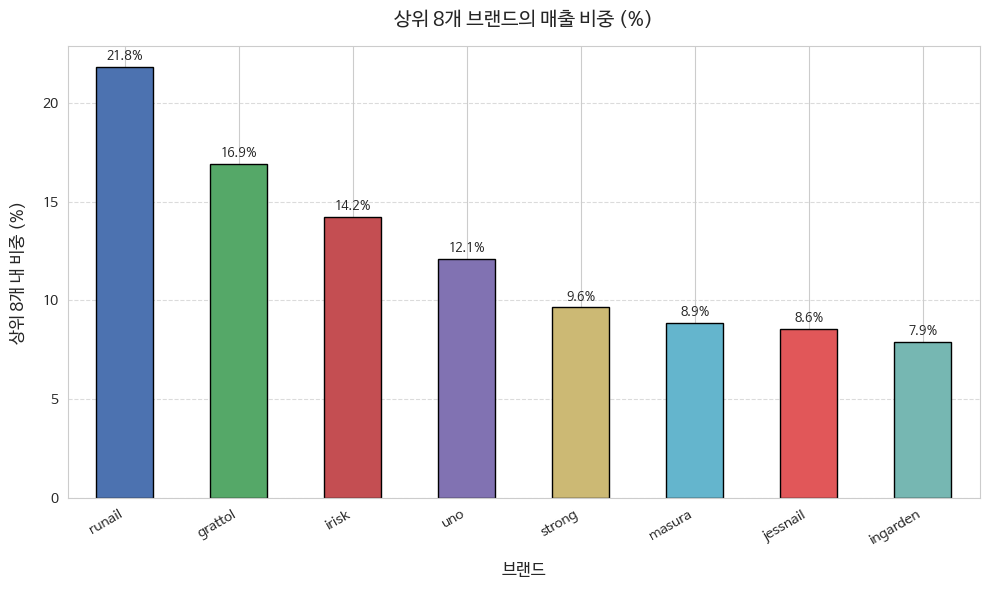

In [ ]:
import matplotlib.pyplot as plt

# 1. 'Unknown' 브랜드를 제외한 순수 브랜드 데이터만 필터링
pure_brand_df = brand_revenue_df[brand_revenue_df['brand'] != 'Unknown'].copy()

# 2. 상위 8개 브랜드 추출
top8_pure = pure_brand_df.head(8).copy()

# 3. 상위 8개 브랜드의 매출 합계를 기준으로 다시 비중(%) 계산
top8_total_sum = top8_pure['total_revenue'].sum()
top8_pure['pure_share'] = (top8_pure['total_revenue'] / top8_total_sum) * 100

# 4. 시각화를 위해 brand를 인덱스로 설정
plot_data_pure8 = top8_pure.set_index('brand')

# 5. Pandas 내장 plot 함수로 Bar 그래프 그리기
ax = plot_data_pure8['pure_share'].plot(
    kind='bar',
    figsize=(10, 6),
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD', '#E15759', '#76B7B2'],
    edgecolor='black'
)

# 6. 그래프 디테일 설정
plt.title('상위 8개 브랜드의 매출 비중 (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('브랜드', fontsize=12, labelpad=10)
plt.ylabel('상위 8개 내 비중 (%)', fontsize=12, labelpad=10)
plt.xticks(rotation=30, ha='right')  # 브랜드명이 8개로 늘어났으므로 살짝 기울여서 가독성 확보
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Bar 상단에 갱신된 백분율 숫자 표시
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

5~8등의 회사들은 매출에 있어 큰 차이가 나지 않음. 상위 4개의 브랜드를 중점적으로 이야기해보도록 하겠습니다.

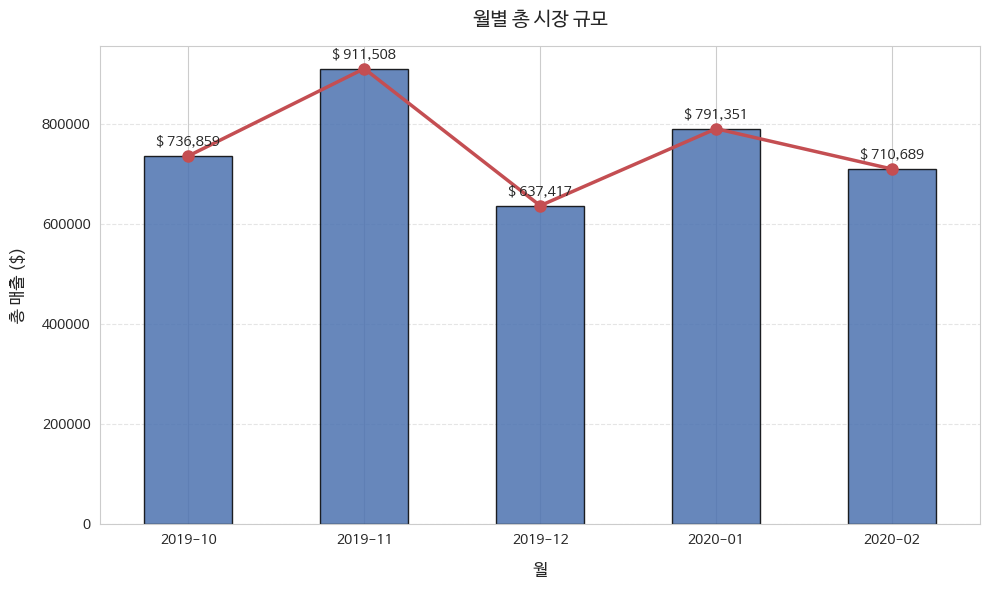

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 월별 총매출을 뽑아오는 SQL 쿼리 (Unknown은 시장 규모 왜곡을 막기 위해 제외)
query_market_size = """
WITH monthly_raw AS (
    SELECT '2019-10' AS month, brand, price FROM events_2019_10 WHERE event_type = 'purchase'
    UNION ALL
    SELECT '2019-11' AS month, brand, price FROM events_2019_11 WHERE event_type = 'purchase'
    UNION ALL
    SELECT '2019-12' AS month, brand, price FROM events_2019_12 WHERE event_type = 'purchase'
    UNION ALL
    SELECT '2020-01' AS month, brand, price FROM events_2020_01 WHERE event_type = 'purchase'
    UNION ALL
    SELECT '2020-02' AS month, brand, price FROM events_2020_02 WHERE event_type = 'purchase'
)
SELECT
    month,
    ROUND(SUM(price), 2) AS total_market_revenue
FROM
    monthly_raw
WHERE
    brand != 'Unknown' -- 순수 브랜드 시장 규모만 집계
GROUP BY
    month
ORDER BY
    month;
"""

# 2. 데이터 로드
market_df = run_query(query_market_size)

# 3. 시각화 구성 (막대 그래프와 선 그래프 동시에 표현)
fig, ax = plt.subplots(figsize=(10, 6))

# 기본 막대 그래프 (시장 규모의 절대적인 크기)
market_df.plot(
    x='month',
    y='total_market_revenue',
    kind='bar',
    ax=ax,
    color='#4C72B0',
    edgecolor='black',
    alpha=0.85,
    legend=False
)

# 추세를 더 잘 보여주는 선 그래프 얹기
market_df.plot(
    x='month',
    y='total_market_revenue',
    kind='line',
    ax=ax,
    color='#C44E52',
    marker='o',
    linewidth=2.5,
    markersize=8,
    legend=False
)

# 4. 그래프 디테일 설정
plt.title('월별 총 시장 규모', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('월', fontsize=12, labelpad=10)
plt.ylabel('총 매출 ($)', fontsize=12, labelpad=10)
plt.xticks(rotation=0)  # 월 레이블 정방향
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 각 달의 총매출액을 막대 위에 텍스트로 표시 (백만 달러 단위 표기나 콤마 표기)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"$ {height:,.0f}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# 1. 상위 4개 브랜드명 가져오기 (Unknown 제외)
top4_brands = brand_revenue_df[brand_revenue_df['brand'] != 'Unknown']['brand'].head(4).tolist()

# 2. 상위 4개 브랜드의 월별 매출을 뽑아오는 SQL 쿼리
query_timeline = f"""
WITH monthly_raw AS (
    SELECT '2019-10' AS month, brand, price, event_type FROM events_2019_10
    UNION ALL
    SELECT '2019-11' AS month, brand, price, event_type FROM events_2019_11
    UNION ALL
    SELECT '2019-12' AS month, brand, price, event_type FROM events_2019_12
    UNION ALL
    SELECT '2020-01' AS month, brand, price, event_type FROM events_2020_01
    UNION ALL
    SELECT '2020-02' AS month, brand, price, event_type FROM events_2020_02
)
SELECT
    month,
    brand,
    ROUND(SUM(price), 2) AS revenue
FROM
    monthly_raw
WHERE
    event_type = 'purchase'
    AND brand IN ({str(top4_brands)[1:-1]})
GROUP BY
    month, brand;
"""

# 3. 데이터 가져오기 및 피벗 테이블 생성
timeline_df = run_query(query_timeline)
pivot_df = timeline_df.pivot(index='month', columns='brand', values='revenue')

# 범례 순서 (runail, grattol, irisk, uno)에 맞게 컬럼 재정렬
ordered_brands = ['runail', 'grattol', 'irisk', 'uno']
pivot_df = pivot_df[ordered_brands] # Reorder columns

# 4. Pandas 내장 plot 함수로 시계열 선 그래프 그리기
ax = pivot_df.plot(
    kind='line',
    figsize=(10, 6),
    marker='o',          # 데이터 포인트에 점 표시
    linewidth=2,         # 선 두께
    color=['#C44E52', '#4C72B0', '#55A868', '#8172B2'] # runail, grattol, irisk, uno 순서에 맞는 색상
)

# 5. 그래프 디테일 설정 (에러를 유발하던 ax.annotate 반복문 제거)
plt.title('상위 4개 브랜드의 월별 매출 추이', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('월', fontsize=12, labelpad=10)
plt.ylabel('매출 ($)', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='브랜드', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

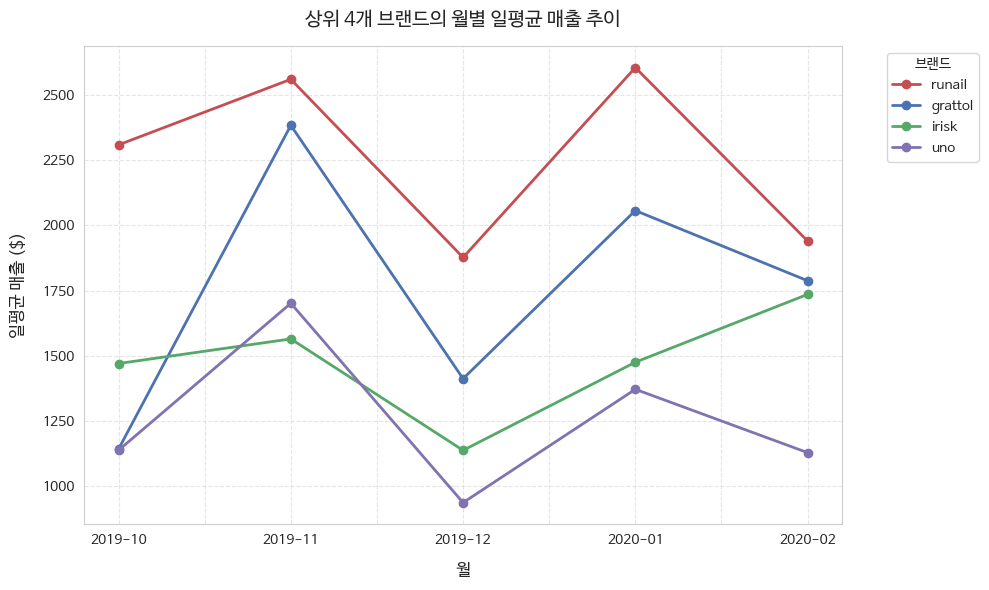

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 강제 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 상위 4개 브랜드명 가져오기 (Unknown 제외)
top4_brands = brand_revenue_df[brand_revenue_df['brand'] != 'Unknown']['brand'].head(4).tolist()

# 2. 상위 4개 브랜드의 월별 일평균 매출을 뽑아오는 SQL 쿼리
query_timeline = f"""
WITH monthly_raw AS (
    SELECT '2019-10' AS month, brand, price, event_time, event_type FROM events_2019_10
    UNION ALL
    SELECT '2019-11' AS month, brand, price, event_time, event_type FROM events_2019_11
    UNION ALL
    SELECT '2019-12' AS month, brand, price, event_time, event_type FROM events_2019_12
    UNION ALL
    SELECT '2020-01' AS month, brand, price, event_time, event_type FROM events_2020_01
    UNION ALL
    SELECT '2020-02' AS month, brand, price, event_time, event_type FROM events_2020_02
)
SELECT
    month,
    brand,
    ROUND(SUM(price) * 1.0 / COUNT(DISTINCT SUBSTR(event_time, 1, 10)), 2) AS daily_avg_revenue
FROM
    monthly_raw
WHERE
    event_type = 'purchase'
    AND brand IN ({str(top4_brands)[1:-1]})
GROUP BY
    month, brand;
"""

# 3. 데이터 가져오기 및 피벗 테이블 생성
timeline_df = run_query(query_timeline)
pivot_df = timeline_df.pivot(index='month', columns='brand', values='daily_avg_revenue')

# 범례 순서 (runail, grattol, irisk, uno)에 맞게 컬럼 재정렬
ordered_brands = ['runail', 'grattol', 'irisk', 'uno']
pivot_df = pivot_df[ordered_brands] # Reorder columns

# 4. Pandas 내장 plot 함수로 시계열 선 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white') # Set figure facecolor to white
ax.set_facecolor('white') # Set axes facecolor to white

pivot_df.plot(
    kind='line',
    ax=ax,
    marker='o',          # 데이터 포인트에 점 표시
    linewidth=2,         # 선 두께
    color=['#C44E52', '#4C72B0', '#55A868', '#8172B2'] # runail, grattol, irisk, uno 순서에 맞는 색상
)

# 5. 그래프 디테일 설정
plt.title('상위 4개 브랜드의 월별 일평균 매출 추이', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('월', fontsize=12, labelpad=10)
plt.ylabel('일평균 매출 ($)', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='브랜드', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

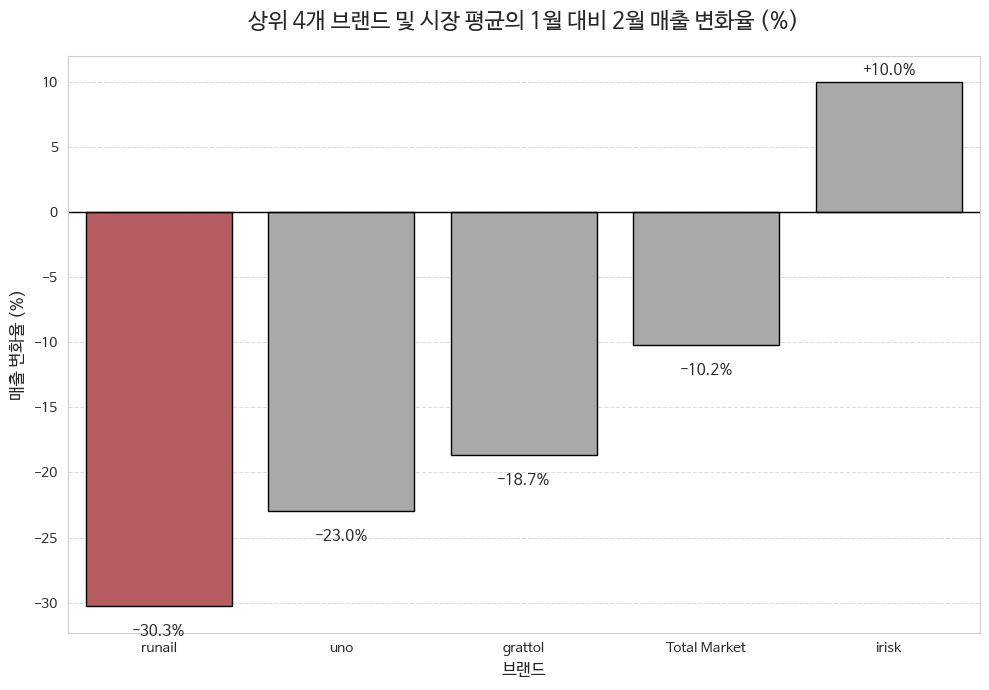

,Brand,Period,Growth Rate (%)
0,runail,1월 → 2월,-30.302932
1,uno,1월 → 2월,-22.979722
2,grattol,1월 → 2월,-18.673462
3,Total Market,1월 → 2월,-10.192976
4,irisk,1월 → 2월,10.011806


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 강제 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 월별 매출 데이터를 가져오는 SQL 쿼리
# 상위 4개 브랜드와 전체 시장 (Unknown 제외)의 01, 02월 매출만 추출
query_monthly_revenue = """
WITH all_purchase_events AS (
    SELECT '2020-01' AS month, brand, price FROM events_2020_01 WHERE event_type = 'purchase'
    UNION ALL
    SELECT '2020-02' AS month, brand, price FROM events_2020_02 WHERE event_type = 'purchase'
),
brand_monthly_revenue AS (
    SELECT
        month,
        brand,
        SUM(price) AS revenue
    FROM all_purchase_events
    WHERE brand IN ('runail', 'grattol', 'irisk', 'uno') -- 상위 4개 브랜드
    GROUP BY month, brand
),
total_market_monthly_revenue AS (
    SELECT
        month,
        'Total Market' AS brand,
        SUM(price) AS revenue
    FROM all_purchase_events
    WHERE brand != 'Unknown' -- Unknown 제외한 전체 시장
    GROUP BY month
)
SELECT * FROM brand_monthly_revenue
UNION ALL
SELECT * FROM total_market_monthly_revenue
ORDER BY month, brand;
"""

df_monthly_revenue = run_query(query_monthly_revenue)

# 2. 피벗 테이블 생성하여 매출 변화율 계산
pivot_revenue = df_monthly_revenue.pivot_table(index='brand', columns='month', values='revenue')

# Top 4 brands and Total Market
target_brands = ['runail', 'grattol', 'irisk', 'uno', 'Total Market']
revenue_data = pivot_revenue.loc[target_brands].copy()

# 3. 매출 변화율 계산 (1월 -> 2월)
growth_rates = []

for brand in target_brands:
    # 1월 -> 2월 변화율
    revenue_jan = revenue_data.loc[brand, '2020-01']
    revenue_feb = revenue_data.loc[brand, '2020-02']

    if pd.notna(revenue_jan) and revenue_jan != 0:
        growth_01_02 = ((revenue_feb - revenue_jan) / revenue_jan) * 100
    else:
        growth_01_02 = 0 # 매출이 없거나 0이면 변화율 0으로 간주

    growth_rates.append({
        'Brand': brand,
        'Period': '1월 → 2월',
        'Growth Rate (%)': growth_01_02
    })

df_growth = pd.DataFrame(growth_rates)

# 4. 시각화 (Bar Chart)
plt.figure(figsize=(10, 7)) # 기간이 줄었으므로 가로 폭을 살짝 줄임
sns.set_style("whitegrid", {'font.family': 'NanumBarunGothic'})

# x-axis order for better readability
df_growth['Brand_Period'] = df_growth['Brand']

# 감소율(가장 낮은 수치) 기준으로 정렬
df_growth_sorted_for_plot = df_growth.sort_values(by='Growth Rate (%)', ascending=True).reset_index(drop=True)

# 색상 지정: runail은 빨간색, 나머지는 모두 회색
bar_colors_sorted = []
for index, row in df_growth_sorted_for_plot.iterrows():
    if row['Brand'] == 'runail':
        bar_colors_sorted.append('#C44E52') # Red for runail
    else:
        bar_colors_sorted.append('#A9A9A9') # Gray for all others

ax = sns.barplot(
    x='Brand_Period',
    y='Growth Rate (%)',
    data=df_growth_sorted_for_plot,
    palette=bar_colors_sorted,
    hue='Brand_Period',
    legend=False,
    edgecolor='black'
)

plt.title('상위 4개 브랜드 및 시장 평균의 1월 대비 2월 매출 변화율 (%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('브랜드', fontsize=12)
plt.ylabel('매출 변화율 (%)', fontsize=12)
plt.xticks(rotation=0) # 항목이 적으므로 글자를 가로로 출력
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    va_dir = 'bottom' if height >= 0 else 'top'
    offset = 3 if height >= 0 else -12
    ax.annotate(f'{height:+.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va=va_dir, fontsize=11, fontweight='bold',
                xytext=(0, offset), textcoords='offset points')

plt.tight_layout()
plt.show()

# 데이터프레임 확인용 출력
display(df_growth_sorted_for_plot[['Brand', 'Period', 'Growth Rate (%)']])

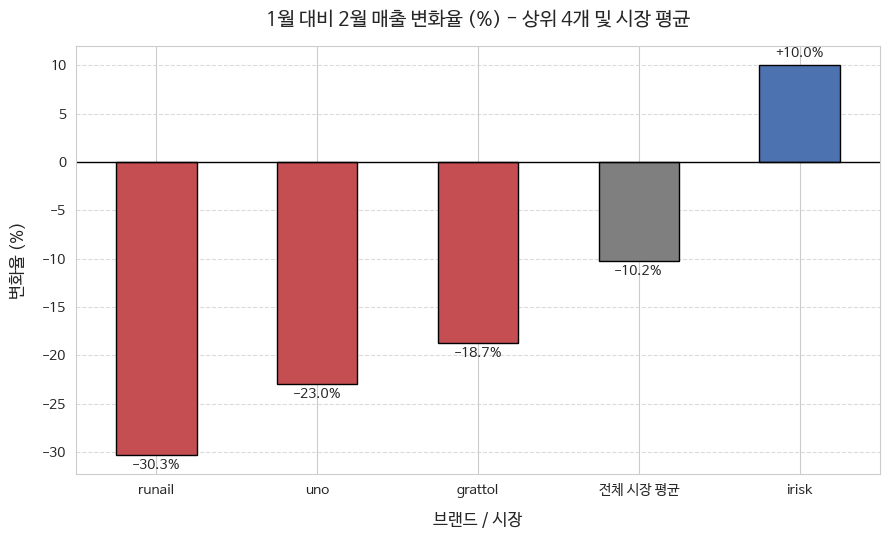

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.font_manager as fm

# 한글 폰트 강제 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 1월과 2월의 전체 브랜드별 매출을 가져오는 깨끗한 SQL 쿼리
query_raw = """
WITH monthly_raw AS (
    SELECT '2020-01' AS month, brand, price FROM events_2020_01 WHERE event_type = 'purchase'
    UNION ALL
    SELECT '2020-02' AS month, brand, price FROM events_2020_02 WHERE event_type = 'purchase'
)
SELECT
    brand,
    month,
    SUM(price) AS revenue
FROM
    monthly_raw
GROUP BY
    brand, month;
"""

# 2. 데이터 로드 및 피벗 변환 (행: brand, 열: month)
df_raw = run_query(query_raw)
pivot_df = df_raw.pivot(index='brand', columns='month', values='revenue')

# 3. [조건 반영] Unknown 제외
pivot_df = pivot_df.drop(index='Unknown', errors='ignore')

# 4. 전체 브랜드(All Pure Brands)의 1월, 2월 총합 계산 (전체 평균용)
all_jan_total = pivot_df['2020-01'].sum()
all_feb_total = pivot_df['2020-02'].sum()

# 5. 전체 매출 기준 상위 4개 브랜드 추출
pivot_df['total_sum'] = pivot_df['2020-01'].fillna(0) + pivot_df['2020-02'].fillna(0)
top4_df = pivot_df.sort_values(by='total_sum', ascending=False).head(4).copy()

# 6. 상위 4개 데이터프레임 하단에 '전체 시장 평균' 행 추가
top4_df.loc['전체 시장 평균'] = [all_jan_total, all_feb_total, all_jan_total + all_feb_total]

# 7. 1월 대비 2월 매출 변화율(%) 계산
top4_df['growth_rate'] = ((top4_df['2020-02'] - top4_df['2020-01']) / top4_df['2020-01']) * 100

# 8. 시각화: 개별 브랜드와 전체 시장 평균(전체 시장 평균)을 구분하기 위해 색상 지정
top4_df_sorted = top4_df.sort_values(by='growth_rate', ascending=True)

colors = []
for idx, row in top4_df_sorted.iterrows():
    if idx == '전체 시장 평균':
        colors.append('#7F7F7F')
    else:
        colors.append('#4C72B0' if row['growth_rate'] >= 0 else '#C44E52')

ax = top4_df_sorted['growth_rate'].plot(
    kind='bar',
    figsize=(9, 5.5),
    color=colors,
    edgecolor='black'
)

# 9. 그래프 디테일 설정
plt.title('1월 대비 2월 매출 변화율 (%) - 상위 4개 및 시장 평균', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('브랜드 / 시장', fontsize=12, labelpad=10)
plt.ylabel('변화율 (%)', fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)

# Bar 상단/하단에 변동 수치 텍스트 매핑 (당겨오기 위해 offset 조정)
for p in ax.patches:
    height = p.get_height()
    va_dir = 'bottom' if height >= 0 else 'top'
    # 오프셋을 더 작게(3/-3) 설정하여 막대 끝에 밀착
    offset = 3 if height >= 0 else -3

    sign = '+' if height > 0 else ''
    ax.annotate(f"{sign}{height:.1f}%",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va=va_dir, fontsize=10, fontweight='bold',
                xytext=(0, offset), textcoords='offset points')

plt.tight_layout()
plt.show()

시장의 침체를 고려하더라도 runail의 매출 변화율은 현저하게 낮음을 확인할 수 있습니다.
runail의 1월 대비 2월 매출은 상위 4개 회사 중 그 감소 폭이 현저하게 커 시장 내 입지가 크게 위축될 우려가 있습니다.

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd


# 1. [핵심 수정] 세션 기반 지표 계산을 위한 통합 SQL 쿼리
query_metrics = """
WITH monthly_metrics AS (
    SELECT '2020-01' AS month, brand, user_session, price, event_type FROM events_2020_01
    UNION ALL
    SELECT '2020-02' AS month, brand, user_session, price, event_type FROM events_2020_02
)
SELECT
    brand,
    month,
    COUNT(DISTINCT user_session) AS total_sessions, -- 총 세션 수 (Total Sessions)

    -- 전환율 (Conversion Rate): (구매 세션 수 / 총 세션 수) * 100
    (COUNT(DISTINCT CASE WHEN event_type='purchase' THEN user_session END) *100.0 /
     COUNT(DISTINCT user_session)) AS session_conv_rate,

    -- 객단가 (Average Order Value): (총 매출 / 구매 세션 수)
    (SUM(CASE WHEN event_type='purchase' THEN price END) /
     NULLIF(COUNT(DISTINCT CASE WHEN event_type='purchase' THEN user_session END), 0))
    AS rev_per_session,

    -- 총 매출 (Revenue): '총 세션 수' * ('전환율' / 100) * '객단가' 로 구성됨
    SUM(CASE WHEN event_type='purchase' THEN price END) AS revenue
FROM monthly_metrics
WHERE brand != 'Unknown'
GROUP BY brand, month;
"""

df_metrics = run_query(query_metrics)
pivot_metrics = df_metrics.pivot(index='brand', columns='month')

# 상위 4개 브랜드 선정
pivot_metrics['total_revenue_sum'] = pivot_metrics[('revenue', '2020-01')].fillna(0) + pivot_metrics[('revenue', '2020-02')].fillna(0)
top4_brands = pivot_metrics.sort_values(by='total_revenue_sum', ascending=False).head(4).index.tolist()

# 2. 변화율 계산 (세션 공식 적용)
final_data = []
target_groups = top4_brands + ['Total Market']

for group in target_groups:
    if group == 'Total Market':
        df_t = df_metrics
        s_jan, s_feb = df_t[df_t['month']=='2020-01']['total_sessions'].sum(), df_t[df_t['month']=='2020-02']['total_sessions'].sum()
        r_jan, r_feb = df_t[df_t['month']=='2020-01']['revenue'].sum(), df_t[df_t['month']=='2020-02']['revenue'].sum()
        # 전체 시장 평균은 전체 세션/구매 기준으로 다시 계산
        c_jan = (df_t[df_t['month']=='2020-01']['session_conv_rate'].mean())
        c_feb = (df_t[df_t['month']=='2020-02']['session_conv_rate'].mean())
        a_jan = (df_t[df_t['month']=='2020-01']['rev_per_session'].mean())
        a_feb = (df_t[df_t['month']=='2020-02']['rev_per_session'].mean())
    else:
        brand_data = pivot_metrics.loc[group]
        s_jan, s_feb = brand_data[('total_sessions', '2020-01')], brand_data[('total_sessions', '2020-02')]
        c_jan, c_feb = brand_data[('session_conv_rate', '2020-01')], brand_data[('session_conv_rate', '2020-02')]
        a_jan, a_feb = brand_data[('rev_per_session', '2020-01')], brand_data[('rev_per_session', '2020-02')]
        r_jan, r_feb = brand_data[('revenue', '2020-01')], brand_data[('revenue', '2020-02')]

    final_data.append({
        '대상의 구분': group,
        '세션 수 변화율 (%)': ((s_feb - s_jan) / s_jan) * 100,
        '전환율 변동 (p.p)': c_feb - c_jan,
        '객단가 변화율 (%)': ((a_feb - a_jan) / a_jan) * 100,
        '최종 매출 변화율 (%)': ((r_feb - r_jan) / r_jan) * 100
    })

report_df = pd.DataFrame(final_data).set_index('대상의 구분')

# 3. 스타일링
cmap = plt.get_cmap('RdBu')
def style_table(val):
    norm = mcolors.Normalize(vmin=-30, vmax=30)
    color = mcolors.to_hex(cmap(norm(val)))
    return f'background-color: {color}; color: {"white" if abs(val) > 15 else "black"}; font-weight: bold; text-align: center;'

styled_table = report_df.style.applymap(style_table)\
    .format("{:+.1f}%", subset=['세션 수 변화율 (%)', '객단가 변화율 (%)', '최종 매출 변화율 (%)'])\
    .format("{:+.2f} p.p", subset=['전환율 변동 (p.p)'])

# Note: The relationship 'Revenue = Total Sessions * (Conversion Rate / 100) * Average Order Value' is inherent
# in how these metrics are defined and calculated. The SQL query directly computes 'revenue',
# and the other metrics (total_sessions, session_conv_rate, rev_per_session) are component parts
# that, when multiplied as per the formula, would equate to the calculated 'revenue'.

styled_table

/tmp/ipykernel_1761/3577791112.py:79: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = report_df.style.applymap(style_table)\


,세션 수 변화율 (%),전환율 변동 (p.p),객단가 변화율 (%),최종 매출 변화율 (%)
대상의 구분,,,,
runail,-13.4%,-0.43 p.p,-15.4%,-30.3%
grattol,-16.4%,-0.67 p.p,+6.6%,-18.7%
irisk,+0.4%,-0.71 p.p,+18.3%,+10.0%
uno,-13.0%,-1.17 p.p,-0.2%,-23.0%
Total Market,-4.9%,-0.33 p.p,-1.5%,-10.2%


(여기서 runail과 평균만을 보여줄지, 상위 4사와 평균을 보여줄지는 조금 더
고민해봐야할듯. 어떤식으로 이 표를 설명할지도 조금 더 고민해봐야함)

현재는 "매출 = 전체세션수 x 세션당전환율 x 세션당구매금액" 의 형태임.

기여율 분석은 그대로 두고 중요도에 따라서 메인을 객단가, 서브를 전환율로 진행

현재는 곱 형태로 이루어져있어 어떤게 가장 크게 기여했는지 파악하기 어려움. 양변에 로그를 취해 합의 형태로 바꿔주자.

In [ ]:
import numpy as np
import pandas as pd

brand_data = pivot_metrics.loc['runail']

# 1월
s1 = brand_data[('total_sessions','2020-01')]
c1 = brand_data[('session_conv_rate','2020-01')] / 100
a1 = brand_data[('rev_per_session','2020-01')]
r1 = brand_data[('revenue','2020-01')]

# 2월
s2 = brand_data[('total_sessions','2020-02')]
c2 = brand_data[('session_conv_rate','2020-02')] / 100
a2 = brand_data[('rev_per_session','2020-02')]
r2 = brand_data[('revenue','2020-02')]

# 로그 변화량
log_session = np.log(s2/s1)
log_conversion = np.log(c2/c1)
log_aov = np.log(a2/a1)
log_revenue = np.log(r2/r1)

# Driver별 로그 변화량
drivers = pd.DataFrame({
    "Driver": [
        "Session",
        "Conversion Rate",
        "Average Order Value"
    ],
    "Log Change":[
        log_session,
        log_conversion,
        log_aov
    ]
})

print(drivers)

print(f"Revenue Log Change : {log_revenue:.6f}")
print(f"Sum of Drivers     : {drivers['Log Change'].sum():.6f}")

                Driver  Log Change
0              Session   -0.144145
1      Conversion Rate   -0.049774
2  Average Order Value   -0.167093
Revenue Log Change : -0.361012
Sum of Drivers     : -0.361012


In [ ]:
drivers["Contribution (%)"] = (
    drivers["Log Change"]
    /
    log_revenue
) * 100

drivers["Contribution (%)"] = drivers["Contribution (%)"].round(1)

drivers

,Driver,Log Change,Contribution (%)
0,Session,-0.144145,39.9
1,Conversion Rate,-0.049774,13.8
2,Average Order Value,-0.167093,46.3


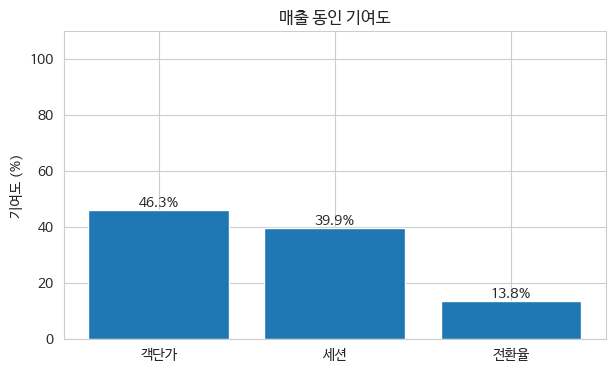

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 강제 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

plot_df = drivers.copy()

# Translate 'Driver' column values to Korean
plot_df['Driver'] = plot_df['Driver'].replace({
    'Session': '세션',
    'Conversion Rate': '전환율',
    'Average Order Value': '객단가'
})

plot_df = plot_df.sort_values(
    'Contribution (%)',
    ascending=False
)

plt.figure(figsize=(7,4))

bars = plt.bar(
    plot_df['Driver'],
    plot_df['Contribution (%)']
)

plt.ylabel('기여도 (%)')
plt.title('매출 동인 기여도')

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+1,
        f'{h:.1f}%',
        ha='center'
    )

plt.ylim(0,110)

plt.show()

이를 통해 객단가 감소와 세션 감소가 매출 감소의 큰 원인임을 파악할 수 있음. 근데 내가 가진 데이터셋엔 세션 감소를 확인할 순 있지만, 세션 감소의 원인을 파악할 컬럼이 존재하지 않는다. 그러므로 어쩔 수 없이 객단가만을 분석한다.

추가로 runail의 전환율은 경쟁사에 비해 변동이 크지 않음을 확인할 수 있음. 하지만, 매출을 결정짓는 요인 중 하나이므로 전환율 분석을 서브 분석으로 진행한다

객단가가 감소했다는 것은 구매한 고객이 예전보다 적은 금액을 구매했다는 것을 의미한다.

"객단가 = 구매당 상품 수 x (구매된) 상품당 평균 가격"으로 계산된다. 그러므로 두 변수의 1월에서 2월로의 변화를 확인해보자.

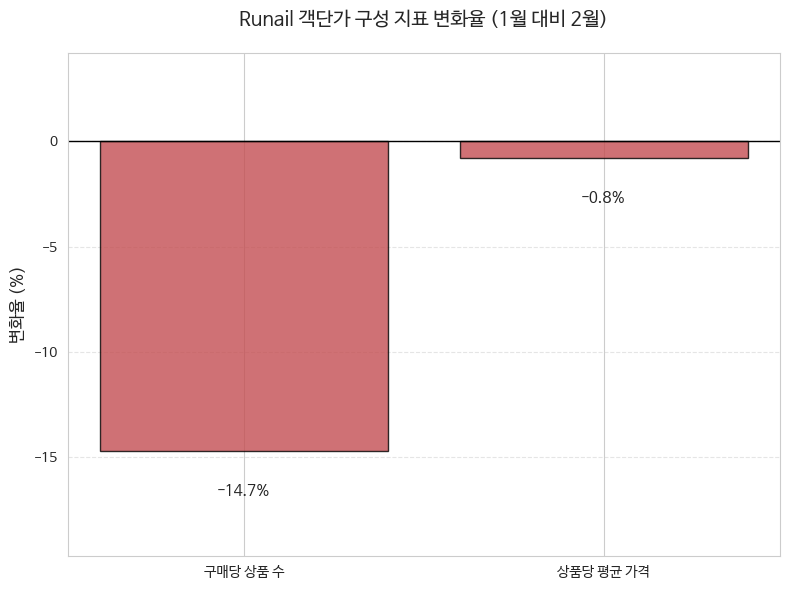

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 준비: runail의 객단가 구성 지표 계산
query_aov_drivers = """
WITH runail_purchase AS (
    SELECT '2020-01' as month, user_session, product_id, price
    FROM events_2020_01 WHERE brand = 'runail' AND event_type = 'purchase'
    UNION ALL
    SELECT '2020-02' as month, user_session, product_id, price
    FROM events_2020_02 WHERE brand = 'runail' AND event_type = 'purchase'
),
session_metrics AS (
    SELECT
        month,
        user_session,
        COUNT(product_id) as item_count,
        SUM(price) as session_revenue
    FROM runail_purchase
    GROUP BY month, user_session
)
SELECT
    month,
    AVG(item_count) as avg_items_per_order,
    SUM(session_revenue) / SUM(item_count) as avg_price_per_item
FROM session_metrics
GROUP BY month;
"""

df_drivers = run_query(query_aov_drivers)
jan = df_drivers[df_drivers['month'] == '2020-01'].iloc[0]
feb = df_drivers[df_drivers['month'] == '2020-02'].iloc[0]

# 변화율 계산
items_growth = ((feb['avg_items_per_order'] - jan['avg_items_per_order']) / jan['avg_items_per_order']) * 100
price_growth = ((feb['avg_price_per_item'] - jan['avg_price_per_item']) / jan['avg_price_per_item']) * 100

summary = pd.DataFrame({
    '지표': ['구매당 상품 수', '상품당 평균 가격'],
    '변화': [f"{items_growth:.1f}%", f"{price_growth:.1f}%"]
})

# 3. 시각화
plot_df = summary.copy()
plot_df['변화율_수치'] = plot_df['변화'].str.replace('%', '').astype(float)

plt.figure(figsize=(8, 6))
colors = ['#C44E52' if x < 0 else '#4C72B0' for x in plot_df['변화율_수치']]

ax = plt.bar(plot_df['지표'], plot_df['변화율_수치'], color=colors, edgecolor='black', alpha=0.8)

plt.title('Runail 객단가 구성 지표 변화율 (1월 대비 2월)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('변화율 (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in ax:
    height = bar.get_height()
    va_dir = 'bottom' if height > 0 else 'top'
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.5 if height > 0 else -1.5),
             f'{height:+.1f}%', ha='center', va=va_dir,
             fontsize=11, fontweight='bold')

plt.ylim(min(plot_df['변화율_수치']) - 5, max(plot_df['변화율_수치']) + 5)
plt.tight_layout()
plt.show()

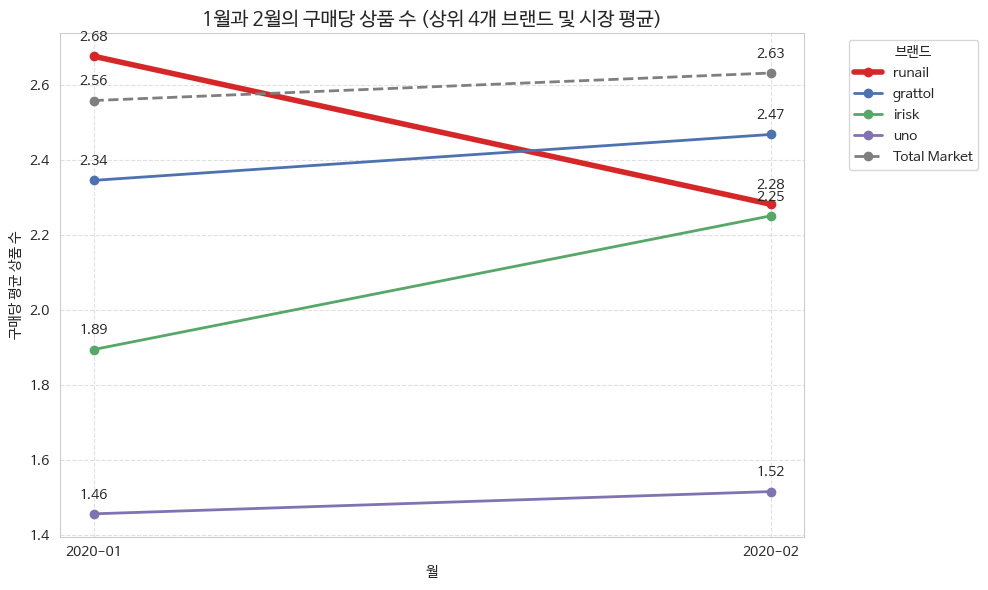

In [ ]:
import matplotlib.font_manager as fm

# 한글 폰트 강제 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

query_comp_trend = """
WITH all_purchase AS (
    SELECT '2020-01' AS month, brand, user_session FROM events_2020_01 WHERE event_type='purchase'
    UNION ALL
    SELECT '2020-02' AS month, brand, user_session FROM events_2020_02 WHERE event_type='purchase'
),
session_metrics AS (
    SELECT
        month,
        brand,
        user_session,
        COUNT(*) AS product_count
    FROM all_purchase
    GROUP BY month, brand, user_session
),
market_metrics AS (
    SELECT
        month,
        'Total Market' AS brand,
        AVG(product_count) AS avg_products_per_order
    FROM session_metrics
    GROUP BY month
),
brand_metrics AS (
    SELECT
        month,
        brand,
        AVG(product_count) AS avg_products_per_order
    FROM session_metrics
    WHERE brand IN ('runail', 'grattol', 'irisk', 'uno')
    GROUP BY month, brand
)
SELECT * FROM brand_metrics
UNION ALL
SELECT * FROM market_metrics
ORDER BY month, avg_products_per_order DESC;
"""

df_comp_trend = run_query(query_comp_trend)

# 시각화를 위한 피벗
pivot_comp = df_comp_trend.pivot(index='month', columns='brand', values='avg_products_per_order')

# 범례 순서 (Runail, Grattol, Irisk, Uno, Total Market)
legend_order = ['runail', 'grattol', 'irisk', 'uno', 'Total Market']

# 그래프 그리기
plt.figure(figsize=(10, 6))
brand_colors = {
    'runail': '#d62728',
    'grattol': '#4C72B0',
    'irisk': '#55A868',
    'uno': '#8172B2',
    'Total Market': '#7F7F7F' # 회색
}

for brand in legend_order:
    if brand in pivot_comp.columns:
        linewidth = 4 if brand == 'runail' else 2
        linestyle = '--' if brand == 'Total Market' else '-'
        color = brand_colors.get(brand, None)

        plt.plot(pivot_comp.index, pivot_comp[brand],
                 marker='o', linewidth=linewidth, linestyle=linestyle,
                 label=brand, color=color)

plt.title('1월과 2월의 구매당 상품 수 (상위 4개 브랜드 및 시장 평균)', fontsize=14, fontweight='bold')
plt.ylabel('구매당 평균 상품 수')
plt.xlabel('월')
plt.grid(True, linestyle='--', alpha=0.6)

# 범례 설정 (순서 유지)
plt.legend(title='브랜드', bbox_to_anchor=(1.05, 1), loc='upper left')

# 수치 표시
for col in pivot_comp.columns:
    for i, val in enumerate(pivot_comp[col]):
        plt.text(i, val + 0.03, f'{val:.2f}', ha='center', va='bottom',
                 fontweight='bold' if col=='runail' else 'normal')

plt.tight_layout()
plt.show()

[객단가] 평균 상품 가격의 변화가 객단가 감소에 있어 유의미한 영향을 줬다고 말할 수 없으며 객단가 감소는 구매당 상품 수의 변화로 인한 것임을 확인할 수 있다.

> 가설2 :신규 고객과 재구매 고객은 주문당 구매 상품 수 감소에 차이가 있을 것이다.



가설2의 결과를 본다면 전체 시장의 신규 고객 구매당상품수 변화율 차이는 13%p, 재구매 고객 차이는 11.7%p이다.

신규/ 재구매 고객 세그먼트에 따른 구매당상품수는 차이는 유의미하지 않다는 결론을 얻을 수 있다.

> 가설3 : 구매 전까지의 탐색 활동이 유의미하게 감소했을 것이다.

구매 전까지 탐색 활동은 구매 세션에서 최초 purchase 이벤트 이전까지 발생한 view와 cart 이벤트의 평균 개수로 정의했다.

In [ ]:
query = """
WITH all_events AS (

    SELECT '2020-01' AS month,
           event_time,
           user_session,
           event_type,
           brand
    FROM events_2020_01

    UNION ALL

    SELECT '2020-02',
           event_time,
           user_session,
           event_type,
           brand
    FROM events_2020_02

),

-- 브랜드별 최초 구매 시각
purchase_time AS (

    SELECT
        brand,
        month,
        user_session,
        MIN(event_time) AS purchase_time

    FROM all_events

    WHERE event_type='purchase'

    GROUP BY
        brand,
        month,
        user_session

),

-- 구매 이전 이벤트
before_purchase AS (

    SELECT

        e.brand,
        e.month,
        e.user_session,
        e.event_type

    FROM all_events e

    JOIN purchase_time p
      ON e.brand = p.brand
     AND e.month = p.month
     AND e.user_session = p.user_session

    WHERE e.event_time < p.purchase_time

),

-- 브랜드별 세션 탐색활동
session_exploration AS (

    SELECT

        brand,
        month,
        user_session,

        SUM(CASE WHEN event_type='view' THEN 1 ELSE 0 END) AS view_cnt,

        SUM(CASE WHEN event_type='cart' THEN 1 ELSE 0 END) AS cart_cnt

    FROM before_purchase

    GROUP BY
        brand,
        month,
        user_session

)

-- runail
SELECT

    'runail' AS target,

    month,

    ROUND(AVG(view_cnt),2) AS avg_view,

    ROUND(AVG(cart_cnt),2) AS avg_cart,

    ROUND(AVG(view_cnt + cart_cnt),2) AS avg_exploration

FROM session_exploration

WHERE brand='runail'

GROUP BY month

UNION ALL

-- Total Market
SELECT

    'Total Market',

    month,

    ROUND(AVG(view_cnt),2),

    ROUND(AVG(cart_cnt),2),

    ROUND(AVG(view_cnt + cart_cnt),2)

FROM session_exploration

GROUP BY month

ORDER BY
    target,
    month;
"""

df_explore = run_query(query)
df_explore

,target,month,avg_view,avg_cart,avg_exploration
0,Total Market,2020-01,2.14,3.05,5.20
1,Total Market,2020-02,2.18,3.16,5.34
2,runail,2020-01,1.85,3.55,5.39
3,runail,2020-02,1.36,2.99,4.34


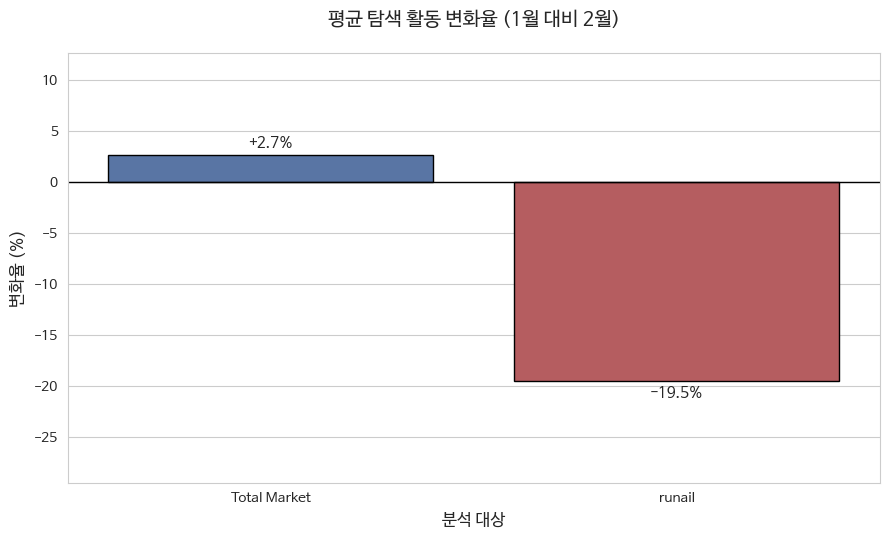

month,2020-01,2020-02,growth_rate
target,,,
Total Market,5.20,5.34,2.692308
runail,5.39,4.34,-19.480519


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 변화율 계산을 위한 피벗
pivot_explore = df_explore.pivot(index='target', columns='month', values='avg_exploration')
pivot_explore['growth_rate'] = ((pivot_explore['2020-02'] - pivot_explore['2020-01']) / pivot_explore['2020-01']) * 100

# 2. 시각화
plt.figure(figsize=(9, 5.5))
sns.set_style("whitegrid", {'font.family': 'NanumBarunGothic'})

# 증가하는 경우 파란색(#4C72B0), 감소하는 경우 빨간색(#C44E52)으로 설정
colors = ['#4C72B0' if x > 0 else '#C44E52' for x in pivot_explore['growth_rate']]
ax = sns.barplot(x=pivot_explore.index, y=pivot_explore['growth_rate'], palette=colors, hue=pivot_explore.index, legend=False, edgecolor='black')

# 3. 그래프 디테일 설정
plt.title('평균 탐색 활동 변화율 (1월 대비 2월)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('변화율 (%)', fontsize=12)
plt.xlabel('분석 대상', fontsize=12)
plt.axhline(0, color='black', linewidth=1)

# 막대 위에 수치 레이블 추가
for p in ax.patches:
    height = p.get_height()
    va_dir = 'bottom' if height > 0 else 'top'
    offset = 3 if height > 0 else -3
    ax.annotate(f'{height:+.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va=va_dir, fontsize=11, fontweight='bold',
                xytext=(0, offset), textcoords='offset points')

plt.ylim(min(pivot_explore['growth_rate']) - 10, max(pivot_explore['growth_rate']) + 10)
plt.tight_layout()
plt.show()

# 데이터프레임 출력
display(pivot_explore[['2020-01', '2020-02', 'growth_rate']])

전체 시장의 구매 전 탐색활동이 증가한 것에 비해, runail의 구매 전 탐색활동은 줄어든 것을 확인할 수 있음.
즉, 탐색활동의 감소와 객단가 감소의 상관관계를 파악해보자

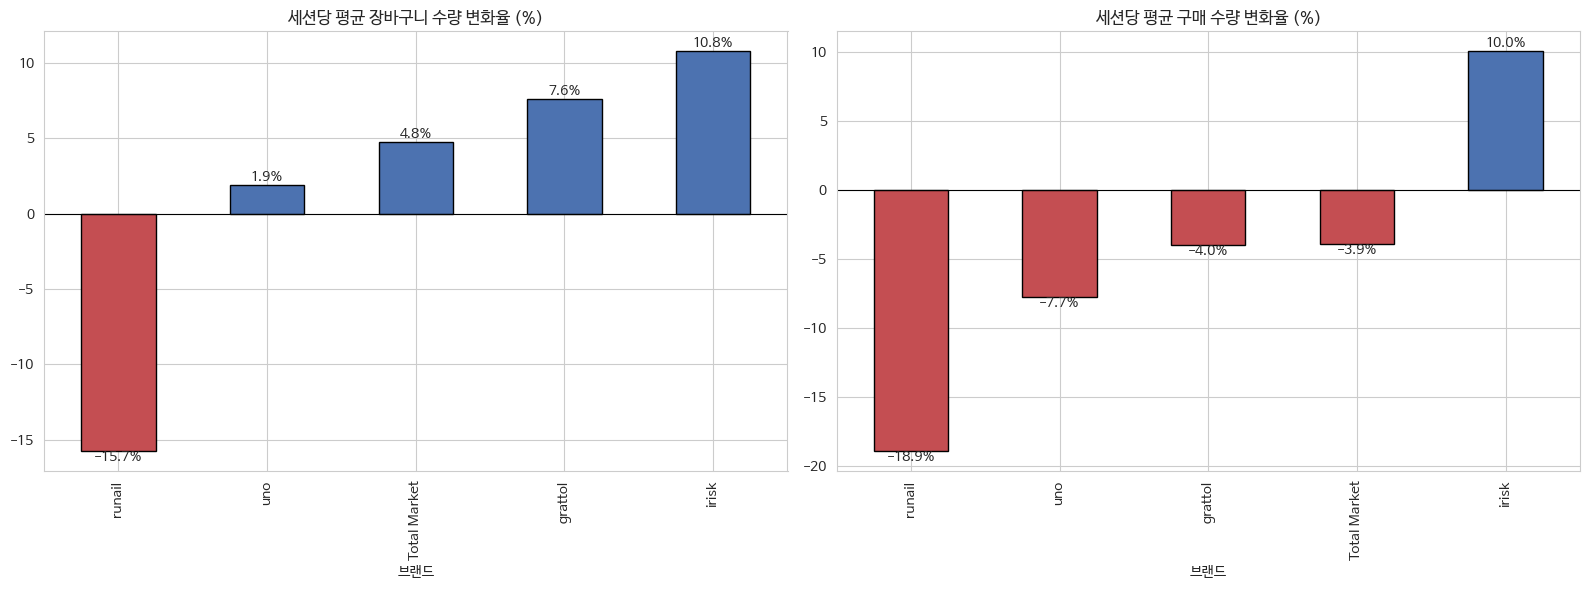

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 강제 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 세션당 장바구니/구매 수량 변화율 분석 SQL (감소율 순 정렬 반영)
query_session_metrics = """
WITH raw_data AS (
    SELECT '2020-01' AS month, brand, user_session, event_type FROM events_2020_01
    UNION ALL
    SELECT '2020-02' AS month, brand, user_session, event_type FROM events_2020_02
),
monthly_stats AS (
    SELECT
        month,
        brand,
        COUNT(DISTINCT user_session) AS sessions,
        COUNT(CASE WHEN event_type = 'cart' THEN 1 END) AS cart_qty,
        COUNT(CASE WHEN event_type = 'purchase' THEN 1 END) AS purchase_qty
    FROM raw_data
    GROUP BY month, brand
),
market_stats AS (
    SELECT
        month,
        'Total Market' AS brand,
        SUM(sessions) AS sessions,
        SUM(cart_qty) AS cart_qty,
        SUM(purchase_qty) AS purchase_qty
    FROM monthly_stats
    GROUP BY month
),
combined AS (
    SELECT * FROM monthly_stats WHERE brand IN ('runail', 'grattol', 'irisk', 'uno')
    UNION ALL
    SELECT * FROM market_stats
),
pivot_data AS (
    SELECT
        brand,
        (MAX(CASE WHEN month='2020-01' THEN cart_qty END) * 1.0 / MAX(CASE WHEN month='2020-01' THEN sessions END)) AS cart_per_sess_jan,
        (MAX(CASE WHEN month='2020-02' THEN cart_qty END) * 1.0 / MAX(CASE WHEN month='2020-02' THEN sessions END)) AS cart_per_sess_feb,
        (MAX(CASE WHEN month='2020-01' THEN purchase_qty END) * 1.0 / MAX(CASE WHEN month='2020-01' THEN sessions END)) AS pur_per_sess_jan,
        (MAX(CASE WHEN month='2020-02' THEN purchase_qty END) * 1.0 / MAX(CASE WHEN month='2020-02' THEN sessions END)) AS pur_per_sess_feb
    FROM combined
    GROUP BY brand
)
SELECT
    brand,
    ((cart_per_sess_feb - cart_per_sess_jan) * 100.0 / cart_per_sess_jan) AS cart_growth_rate,
    ((pur_per_sess_feb - pur_per_sess_jan) * 100.0 / pur_per_sess_jan) AS purchase_growth_rate
FROM pivot_data;
"""

df_session_growth = run_query(query_session_metrics)

# 2. 시각화 (감소율이 낮은 순서 = 변화율 오름차순으로 정렬)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 세션당 장바구니 수량 변화율 정렬
df_cart_sorted = df_session_growth.sort_values('cart_growth_rate', ascending=True)
colors_cart = ['#C44E52' if x < 0 else '#4C72B0' for x in df_cart_sorted['cart_growth_rate']]
ax1 = df_cart_sorted.plot(kind='bar', x='brand', y='cart_growth_rate', color=colors_cart, ax=axes[0], legend=False, edgecolor='black')
axes[0].set_title('세션당 평균 장바구니 수량 변화율 (%)', fontweight='bold')
axes[0].set_xlabel('브랜드')
axes[0].axhline(0, color='black', linewidth=0.8)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom' if p.get_height() > 0 else 'top', fontweight='bold')

# (2) 세션당 구매 수량 변화율 정렬
df_pur_sorted = df_session_growth.sort_values('purchase_growth_rate', ascending=True)
colors_pur = ['#C44E52' if x < 0 else '#4C72B0' for x in df_pur_sorted['purchase_growth_rate']]
ax2 = df_pur_sorted.plot(kind='bar', x='brand', y='purchase_growth_rate', color=colors_pur, ax=axes[1], legend=False, edgecolor='black')
axes[1].set_title('세션당 평균 구매 수량 변화율 (%)', fontweight='bold')
axes[1].set_xlabel('브랜드')
axes[1].axhline(0, color='black', linewidth=0.8)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom' if p.get_height() > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

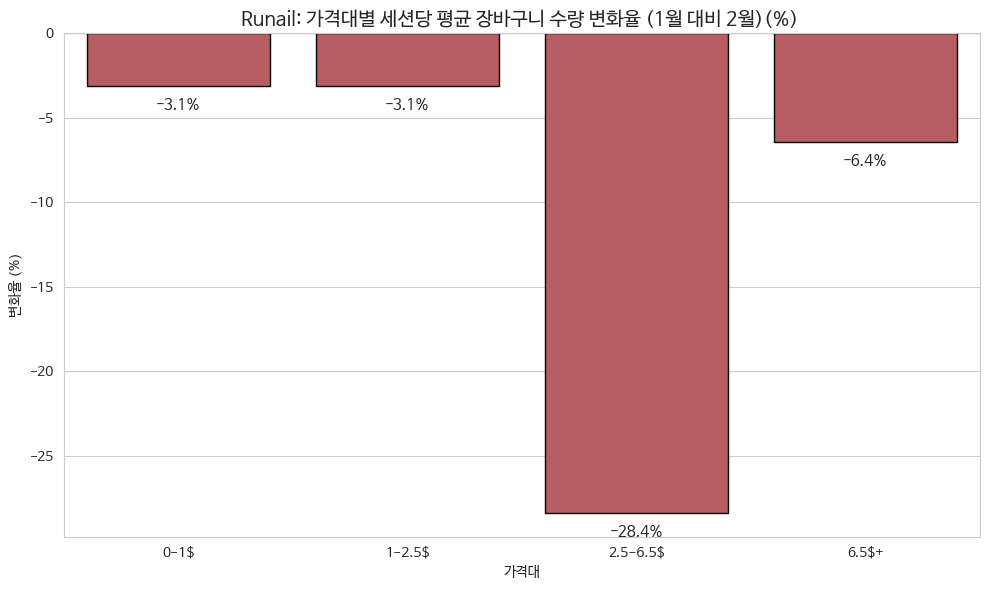

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 폰트 깨짐 방지를 위한 강제 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

query_price_cart_growth = """
WITH monthly_data AS (
    SELECT '2020-01' AS month, price, user_session, event_type FROM events_2020_01 WHERE brand = 'runail'
    UNION ALL
    SELECT '2020-02' AS month, price, user_session, event_type FROM events_2020_02 WHERE brand = 'runail'
),
segmented_data AS (
    SELECT
        month,
        user_session,
        event_type,
        CASE
            WHEN price >= 0 AND price < 1 THEN '0-1$'
            WHEN price >= 1 AND price < 2.5 THEN '1-2.5$'
            WHEN price >= 2.5 AND price < 6.5 THEN '2.5-6.5$'
            ELSE '6.5$+'
        END AS price_range
    FROM monthly_data
),
metrics AS (
    SELECT
        month,
        price_range,
        COUNT(DISTINCT user_session) AS sessions,
        COUNT(CASE WHEN event_type = 'cart' THEN 1 END) AS carts
    FROM segmented_data
    GROUP BY month, price_range
),
pivot_metrics AS (
    SELECT
        price_range,
        MAX(CASE WHEN month = '2020-01' THEN CAST(carts AS REAL)/sessions END) AS jan_carts_per_sess,
        MAX(CASE WHEN month = '2020-02' THEN CAST(carts AS REAL)/sessions END) AS feb_carts_per_sess
    FROM metrics
    GROUP BY price_range
)
SELECT
    price_range,
    jan_carts_per_sess,
    feb_carts_per_sess,
    ((feb_carts_per_sess - jan_carts_per_sess) / jan_carts_per_sess) * 100 AS growth_rate
FROM pivot_metrics
ORDER BY
    CASE
        WHEN price_range = '0-1$' THEN 1
        WHEN price_range = '1-2.5$' THEN 2
        WHEN price_range = '2.5-6.5$' THEN 3
        WHEN price_range = '6.5$+' THEN 4
    END;
"""

df_price_growth = run_query(query_price_cart_growth)

plt.figure(figsize=(10, 6))

# Seaborn 스타일 설정 시 폰트 명시
sns.set_style("whitegrid", {'font.family': 'NanumBarunGothic'})

colors = ['#C44E52' if x < 0 else '#4C72B0' for x in df_price_growth['growth_rate']]
ax = sns.barplot(x='price_range', y='growth_rate', data=df_price_growth, palette=colors, hue='price_range', legend=False, edgecolor='black')

plt.title('Runail: 가격대별 세션당 평균 장바구니 수량 변화율 (1월 대비 2월)(%) ', fontsize=14, fontweight='bold')

plt.ylabel('변화율 (%)')
plt.xlabel('가격대')
plt.axhline(0, color='black', linewidth=0.8)

# 간격 조정을 위해 xytext 오프셋을 수정 (5 -> 2, -15 -> -12)
for p in ax.patches:
    height = p.get_height()
    va_dir = 'bottom' if height > 0 else 'top'
    ax.annotate(f'{height:+.1f}%', (p.get_x() + p.get_width() / 2., height),
                ha='center', va=va_dir, fontsize=11, fontweight='bold',
                xytext=(0,0 if height > 0 else -8), textcoords='offset points')

plt.tight_layout()
plt.show()

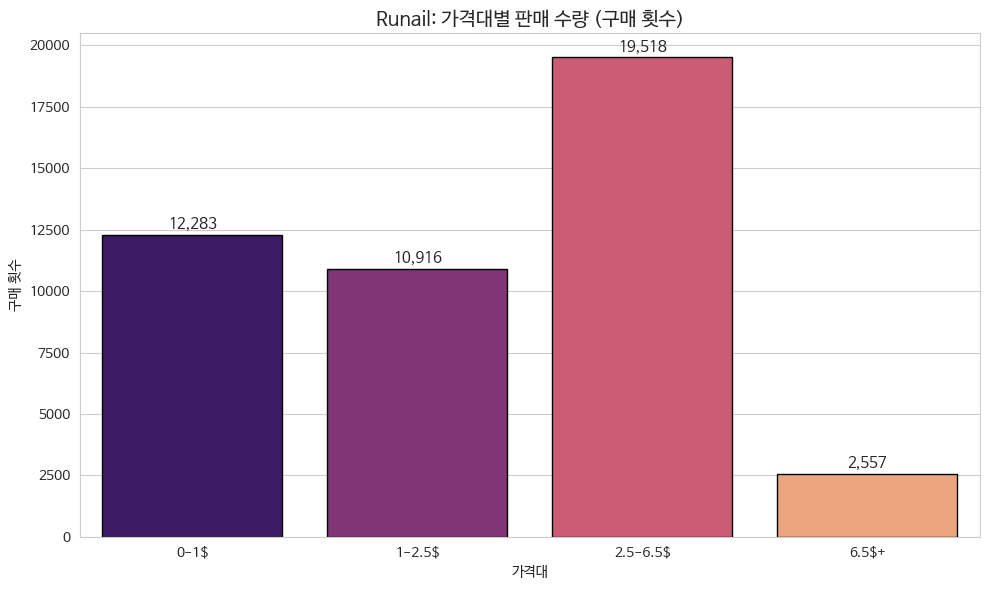

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 폰트 깨짐 방지를 위한 강제 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

query_price_sales = """
WITH runail_purchases AS (
    SELECT price, event_type FROM events_2020_01 WHERE brand = 'runail' AND event_type = 'purchase'
    UNION ALL
    SELECT price, event_type FROM events_2020_02 WHERE brand = 'runail' AND event_type = 'purchase'
)
SELECT
    CASE
        WHEN price >= 0 AND price < 1 THEN '0-1$'
        WHEN price >= 1 AND price < 2.5 THEN '1-2.5$'
        WHEN price >= 2.5 AND price < 6.5 THEN '2.5-6.5$'
        ELSE '6.5$+'
    END AS price_range,
    COUNT(*) AS purchase_count
FROM runail_purchases
GROUP BY price_range
ORDER BY
    CASE
        WHEN price_range = '0-1$' THEN 1
        WHEN price_range = '1-2.5$' THEN 2
        WHEN price_range = '2.5-6.5$' THEN 3
        ELSE 4
    END;
"""

df_price_sales = run_query(query_price_sales)

plt.figure(figsize=(10, 6))
# 수정된 부분: Seaborn 스타일을 설정할 때 폰트를 명시적으로 함께 전달합니다.
sns.set_style("whitegrid", {'font.family': 'NanumBarunGothic'})
ax = sns.barplot(x='price_range', y='purchase_count', data=df_price_sales, palette='magma', hue='price_range', legend=False, edgecolor='black')

plt.title('Runail: 가격대별 판매 수량 (구매 횟수)', fontsize=14, fontweight='bold')
plt.ylabel('구매 횟수')
plt.xlabel('가격대')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

--- Runail 제품 판매 수량 가중 사분위수 및 통계적 경계 ($0~$10) ---
Q1 (25th percentile): $0.7
Q2 (50th percentile, Median): $2.4
Outlier Upper Bound (Q3 + 1.5*IQR): $6.2
Weighted Percentile Rank for $10: 99.91%


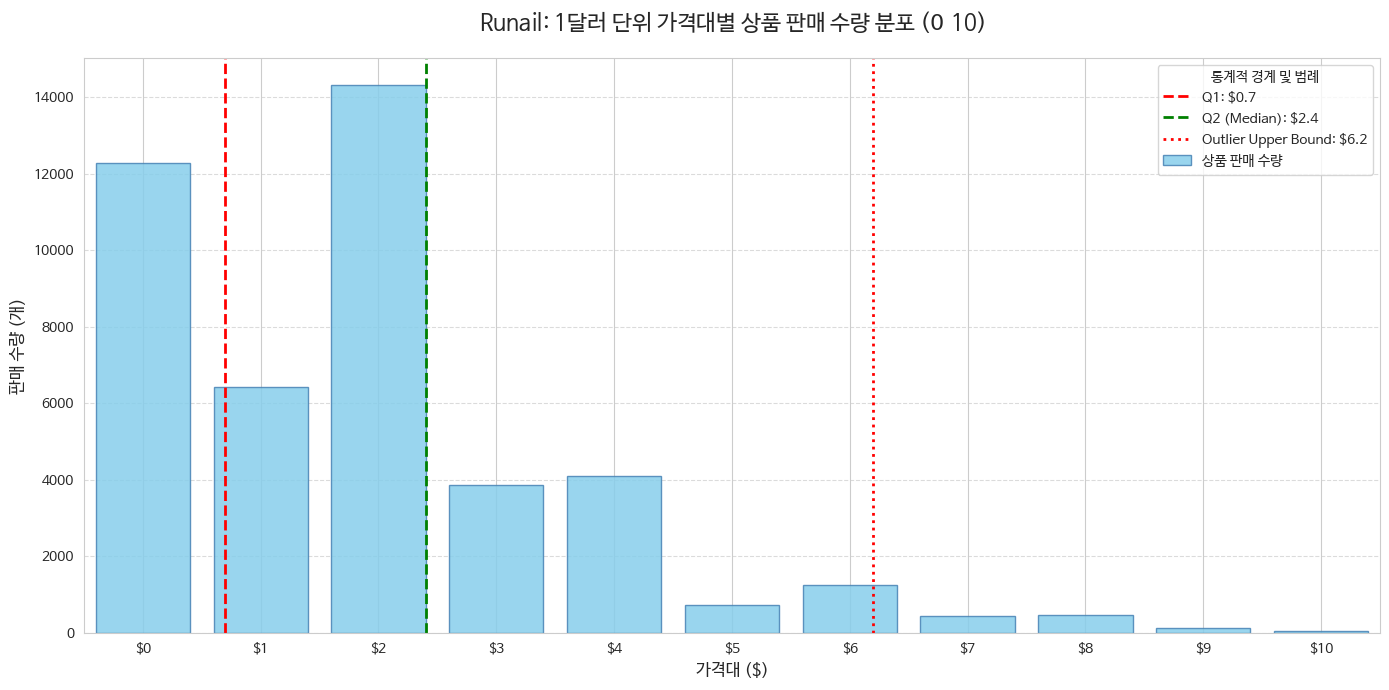

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 한글 폰트 설정 (Colab / Linux 환경)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. runail 브랜드 상품 가격 데이터 쿼리 ($0 ~ $10 구간 조회를 위해 11달러 미만 검색)
query_product_sales_0_1_interval = """
WITH runail_purchases AS (
    SELECT price, product_id
    FROM events_2020_01
    WHERE brand = 'runail' AND event_type = 'purchase'
    UNION ALL
    SELECT price, product_id
    FROM events_2020_02
    WHERE brand = 'runail' AND event_type = 'purchase'
)
SELECT
    CAST(ROUND(price / 0.1) * 0.1 AS REAL) AS price_bucket_start,
    COUNT(product_id) AS product_sales_count
FROM runail_purchases
WHERE price >= 0 AND price < 11.0
GROUP BY price_bucket_start
ORDER BY price_bucket_start ASC;
"""

df_price_sales_0_1 = run_query(query_product_sales_0_1_interval)

# 2. 통계량 계산 (Q1, Q2, 이상치 상한선)
df_sorted = df_price_sales_0_1.sort_values(by='price_bucket_start').reset_index(drop=True)
df_sorted['cumulative_sales'] = df_sorted['product_sales_count'].cumsum()
total_sales = df_sorted['product_sales_count'].sum()

# 사분위수 계산
q1_target = 0.25 * total_sales
q1_price = df_sorted[df_sorted['cumulative_sales'] >= q1_target]['price_bucket_start'].iloc[0]

q2_target = 0.50 * total_sales
q2_price = df_sorted[df_sorted['cumulative_sales'] >= q2_target]['price_bucket_start'].iloc[0]

q3_target = 0.75 * total_sales
q3_price = df_sorted[df_sorted['cumulative_sales'] >= q3_target]['price_bucket_start'].iloc[0]

iqr = q3_price - q1_price
outlier_upper_bound = q3_price + 1.5 * iqr

# $10 이하 누적 판매 비율
price_10_cumulative_sales = df_sorted[df_sorted['price_bucket_start'] <= 10.0]['product_sales_count'].sum()
percentile_rank_10 = (price_10_cumulative_sales / total_sales) * 100

print(f"--- Runail 제품 판매 수량 가중 사분위수 및 통계적 경계 ($0~$10) ---")
print(f"Q1 (25th percentile): ${q1_price:.1f}")
print(f"Q2 (50th percentile, Median): ${q2_price:.1f}")
print(f"Outlier Upper Bound (Q3 + 1.5*IQR): ${outlier_upper_bound:.1f}")
print(f"Weighted Percentile Rank for $10: {percentile_rank_10:.2f}%")

# 3. 1달러 단위 재집계
df_sorted['price_1d'] = df_sorted['price_bucket_start'].astype(int)
df_1d = df_sorted.groupby('price_1d', as_index=False)['product_sales_count'].sum()

# 4. 1달러 단위 막대그래프 시각화 ($0 ~ $10)
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid", {'font.family': 'NanumBarunGothic'})

# 막대그래프 생성
bars = plt.bar(
    df_1d['price_1d'],
    df_1d['product_sales_count'],
    width=0.8,
    color='skyblue',
    edgecolor='steelblue',
    alpha=0.85,
    label='상품 판매 수량'
)

# Q1, Q2 수직선 표시
plt.axvline(x=q1_price, color='red', linestyle='--', linewidth=2, label=f'Q1: ${q1_price:.1f}')
plt.axvline(x=q2_price, color='green', linestyle='--', linewidth=2, label=f'Q2 (Median): ${q2_price:.1f}')

# 이상치 상한선이 $10 이하일 때만 그래프 내에 표시
if outlier_upper_bound <= 10:
    plt.axvline(x=outlier_upper_bound, color='red', linestyle=':', linewidth=2, label=f'Outlier Upper Bound: ${outlier_upper_bound:.1f}')

# 그래프 스타일 및 축 범위 설정 ($0 ~ $10)
plt.title('Runail: 1달러 단위 가격대별 상품 판매 수량 분포 ($0 ~ $10)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('가격대 ($)', fontsize=12)
plt.ylabel('판매 수량 (개)', fontsize=12)

# X축 $0 ~ $10 설정
plt.xticks(range(0, 11, 1), [f'${i}' for i in range(0, 11, 1)], rotation=0)
plt.xlim(-0.5, 10.5)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='통계적 경계 및 범례', loc='upper right')
plt.tight_layout()
plt.show()

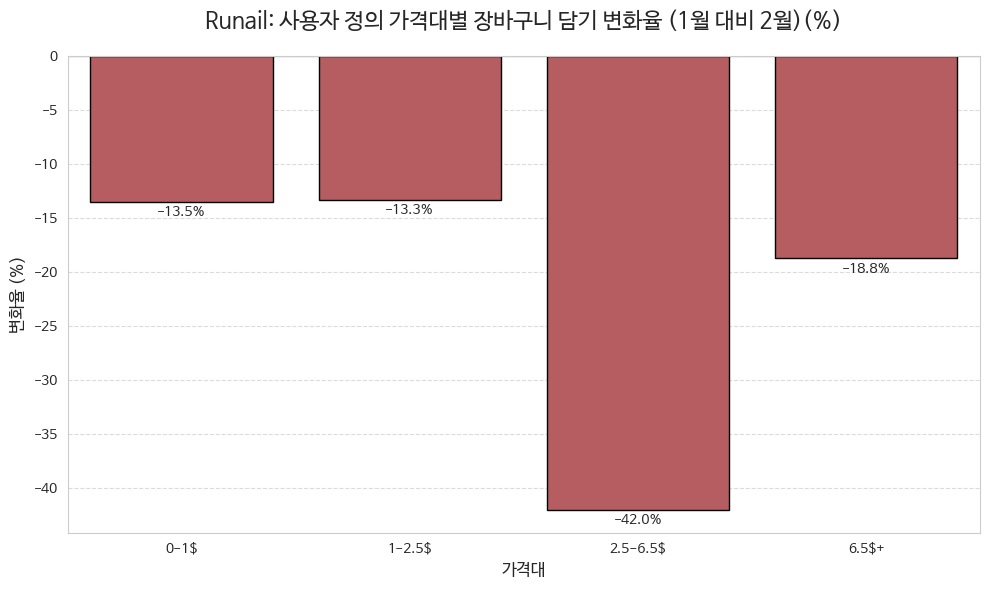

Runail 1월 대비 2월 사용자 정의 가격대별 장바구니 담기 변화율:


,price_range,jan_cart_qty,feb_cart_qty,growth_rate
0,0-1$,34903,30178,-13.537518
1,1-2.5$,21801,18897,-13.320490
2,2.5-6.5$,55247,32027,-42.029431
3,6.5$+,5226,4246,-18.752392


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 한글 폰트 강제 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. runail 브랜드의 장바구니에 담긴 상품의 가격별 수량을 새로운 가격대 기준으로 집계하고 1월 대비 2월 변화율 계산
query_custom_price_range_cart_growth = """
WITH runail_carts AS (
    SELECT '2020-01' AS month, price, product_id
    FROM events_2020_01
    WHERE brand = 'runail' AND event_type = 'cart'
    UNION ALL
    SELECT '2020-02' AS month, price, product_id
    FROM events_2020_02
    WHERE brand = 'runail' AND event_type = 'cart'
),
monthly_cart_counts AS (
    SELECT
        month,
        CASE
            WHEN price >= 0 AND price < 1 THEN '0-1$'
            WHEN price >= 1 AND price < 2.5 THEN '1-2.5$'
            WHEN price >= 2.5 AND price < 6.5 THEN '2.5-6.5$'
            WHEN price >= 6.5 AND price < 40 THEN '6.5$+' -- 상위 가격대 제한을 40$로 설정
            ELSE 'Other' -- 지정되지 않은 가격대 처리
        END AS price_range,
        COUNT(product_id) AS cart_quantity
    FROM runail_carts
    WHERE price >= 0 AND price < 40 -- 데이터 범위 확장
    GROUP BY month, price_range
),
pivot_data AS (
    SELECT
        price_range,
        SUM(CASE WHEN month = '2020-01' THEN cart_quantity ELSE 0 END) AS jan_cart_qty,
        SUM(CASE WHEN month = '2020-02' THEN cart_quantity ELSE 0 END) AS feb_cart_qty
    FROM monthly_cart_counts
    GROUP BY price_range
)
SELECT
    price_range,
    jan_cart_qty,
    feb_cart_qty,
    ((CAST(feb_cart_qty AS REAL) - jan_cart_qty) * 100.0 / NULLIF(jan_cart_qty, 0)) AS growth_rate
FROM pivot_data
WHERE price_range != 'Other'
ORDER BY
    CASE price_range
        WHEN '0-1$' THEN 1
        WHEN '1-2.5$' THEN 2
        WHEN '2.5-6.5$' THEN 3
        WHEN '6.5$+' THEN 4
    END;
"""

df_custom_cart_growth = run_query(query_custom_price_range_cart_growth)

# growth_rate 열을 다시 계산.
# 분모가 0인 경우를 처리:
# - jan_cart_qty가 0이고 feb_cart_qty도 0이면 growth_rate는 0.
# - jan_cart_qty가 0인데 feb_cart_qty가 0이 아니면 10000 (무한대 증가를 표현하기 위한 임의의 큰 값).
# - 그 외의 경우는 정상적인 변화율 계산.
df_custom_cart_growth['growth_rate'] = df_custom_cart_growth.apply(
    lambda row: ((row['feb_cart_qty'] - row['jan_cart_qty']) * 100.0 / row['jan_cart_qty'])
    if row['jan_cart_qty'] > 0 else (0 if row['feb_cart_qty'] == 0 else 10000),
    axis=1
)

# 2. 막대 그래프 시각화
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid", {'font.family': 'NanumBarunGothic'})

colors = ['#C44E52' if x < 0 else '#4C72B0' for x in df_custom_cart_growth['growth_rate']]
ax = sns.barplot(
    x='price_range',
    y='growth_rate',
    data=df_custom_cart_growth,
    palette=colors,
    hue='price_range',
    legend=False,
    edgecolor='black'
)

plt.title('Runail: 사용자 정의 가격대별 장바구니 담기 변화율 (1월 대비 2월)(%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('가격대', fontsize=12)
plt.ylabel('변화율 (%)', fontsize=12)

plt.axhline(0, color='black', linewidth=0.8) # 0% 변화율 기준선
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 수치 레이블 추가
for p in ax.patches:
    height = p.get_height()
    va_dir = 'bottom' if height > 0 else 'top'
    offset = 3 if height > 0 else -3

    # Format numbers, capping very large percentages for readability
    if abs(height) >= 1000: # If rate is >= 1000%, display as ">999%" or "<-999%"
        text_val = '>999%' if height > 0 else '<-999%'
    else:
        text_val = f'{height:+.1f}%'

    ax.annotate(text_val,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va=va_dir, fontsize=10, fontweight='bold',
                xytext=(0, offset), textcoords='offset points')

plt.tight_layout()
plt.show()

print("Runail 1월 대비 2월 사용자 정의 가격대별 장바구니 담기 변화율:")
display(df_custom_cart_growth[['price_range', 'jan_cart_qty', 'feb_cart_qty', 'growth_rate']])

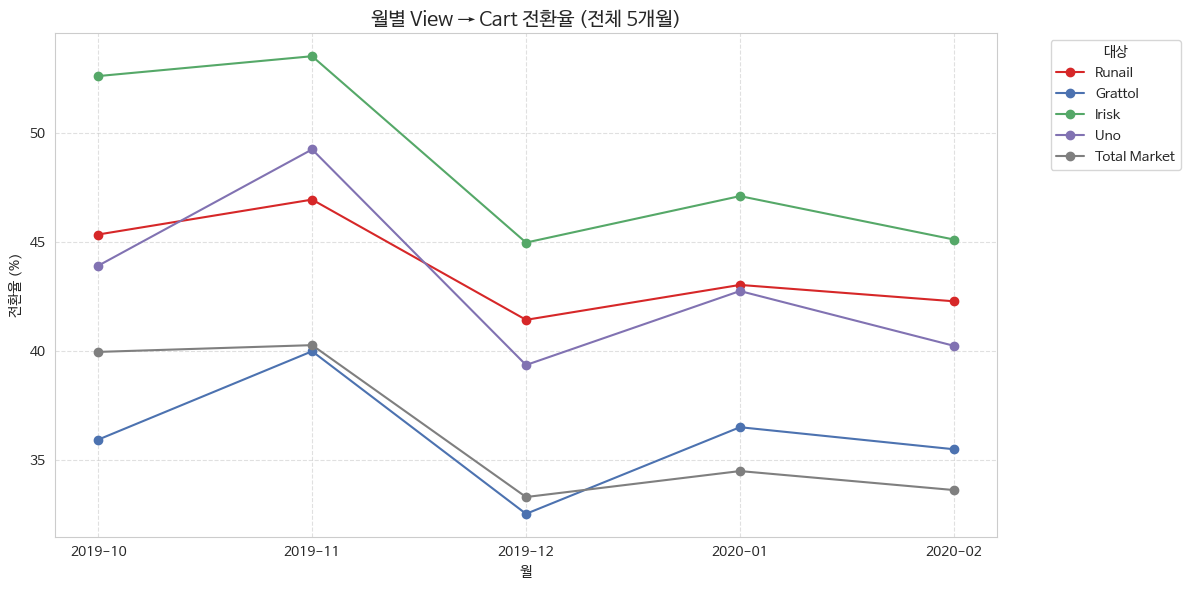

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.font_manager as fm
import platform

# 운영체제에 맞는 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'    # 맥: 애플 고딕

# 마이너스 폰트 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

query_funnel_all_months = """
WITH all_events AS (
    SELECT '2019-10' AS month, brand, product_id, event_type, user_session FROM events_2019_10
    UNION ALL
    SELECT '2019-11' AS month, brand, product_id, event_type, user_session FROM events_2019_11
    UNION ALL
    SELECT '2019-12' AS month, brand, product_id, event_type, user_session FROM events_2019_12
    UNION ALL
    SELECT '2020-01' AS month, brand, product_id, event_type, user_session FROM events_2020_01
    UNION ALL
    SELECT '2020-02' AS month, brand, product_id, event_type, user_session FROM events_2020_02
),
brand_funnel_counts AS (
    SELECT
        month, brand,
        COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_session END) AS views,
        COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_session END) AS carts,
        COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_session END) AS purchases
    FROM all_events WHERE brand != 'Unknown'
    GROUP BY month, brand
),
market_funnel_counts AS (
    SELECT month, 'Total Market' AS brand, SUM(views) AS views, SUM(carts) AS carts, SUM(purchases) AS purchases
    FROM brand_funnel_counts GROUP BY month
),
combined_funnel AS (
    SELECT * FROM brand_funnel_counts WHERE brand IN ('runail', 'grattol', 'irisk', 'uno')
    UNION ALL
    SELECT * FROM market_funnel_counts
)
SELECT
    month,
    CASE
        WHEN brand = 'runail' THEN 'Runail'
        WHEN brand = 'grattol' THEN 'Grattol'
        WHEN brand = 'irisk' THEN 'Irisk'
        WHEN brand = 'uno' THEN 'Uno'
        ELSE brand
    END AS target,
    ROUND(CAST(carts AS REAL) * 100.0 / NULLIF(views, 0), 2) AS view_to_cart_rate,
    ROUND(CAST(purchases AS REAL) * 100.0 / NULLIF(carts, 0), 2) AS cart_to_purchase_rate
FROM combined_funnel
ORDER BY month, target;
"""

df_funnel_all = run_query(query_funnel_all_months)

pivot_view_to_cart = df_funnel_all.pivot_table(index='month', columns='target', values='view_to_cart_rate')

colors = {'Runail': '#d62728', 'Grattol': '#4C72B0', 'Irisk': '#55A868', 'Uno': '#8172B2', 'Total Market': '#7F7F7F'}
plot_order = ['Runail', 'Grattol', 'Irisk', 'Uno', 'Total Market']

plt.figure(figsize=(12, 6))
for target in plot_order:
    if target in pivot_view_to_cart.columns:
        plt.plot(pivot_view_to_cart.index, pivot_view_to_cart[target], marker='o', label=target, color=colors.get(target))
plt.title('월별 View → Cart 전환율 (전체 5개월)', fontsize=14, fontweight='bold')
plt.xlabel('월')
plt.ylabel('전환율 (%)')
plt.legend(title='대상', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

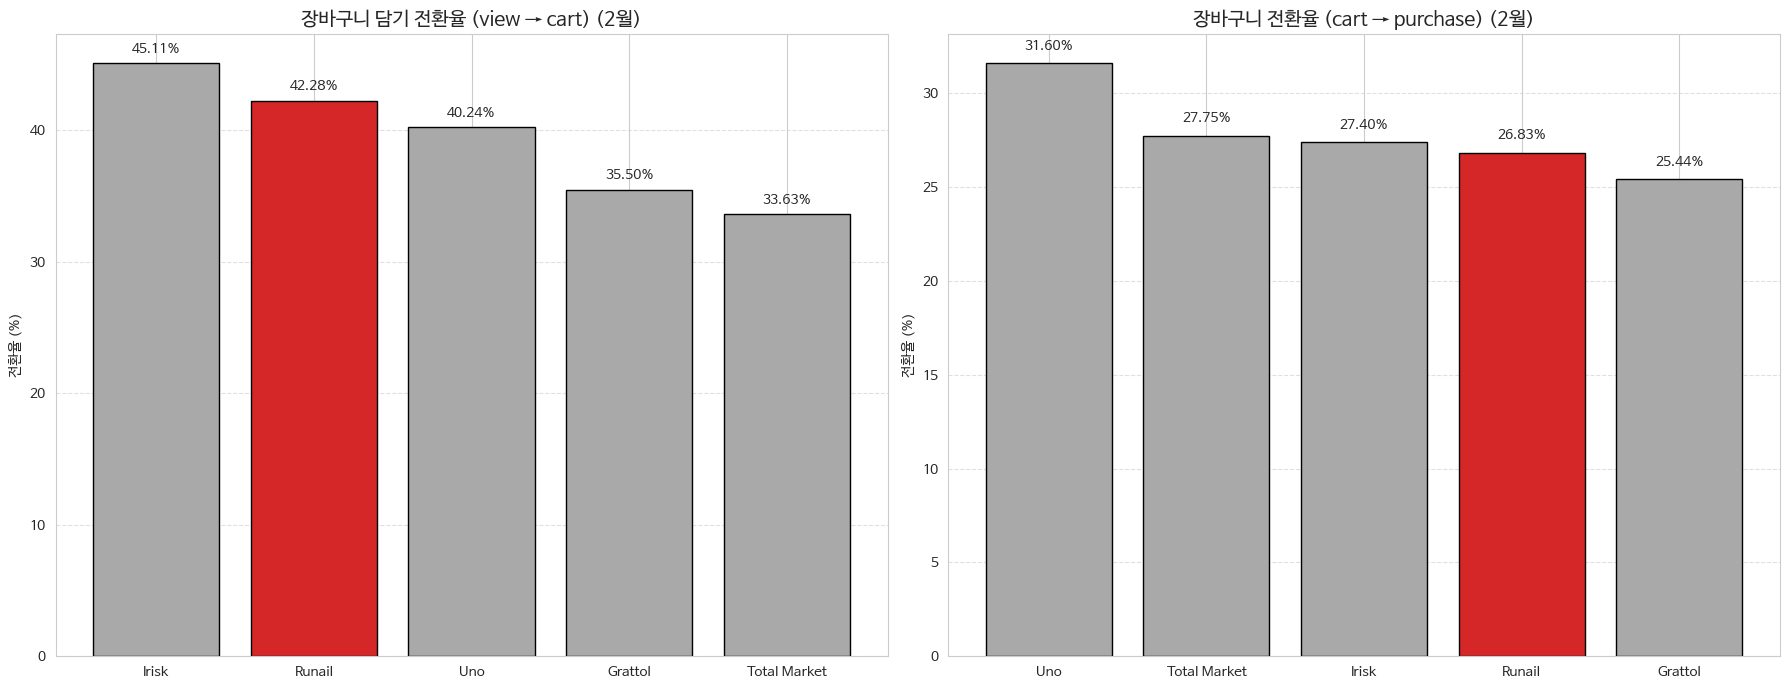

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import platform

# 폰트 및 마이너스 기호 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2월 데이터 필터링
df_feb_funnel = df_funnel_all[df_funnel_all['month'] == '2020-02'].copy()
selected_targets = ['Runail', 'Grattol', 'Irisk', 'Uno', 'Total Market']
df_feb_selected = df_feb_funnel[df_feb_funnel['target'].isin(selected_targets)].copy()

# 1x2 서브프롡 생성
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- (죌) View → Cart 전환율 ---
df_v_c = df_feb_selected.sort_values('view_to_cart_rate', ascending=False)
colors_vc = ['#d62728' if t == 'Runail' else '#A9A9A9' for t in df_v_c['target']]
bars1 = axes[0].bar(df_v_c['target'], df_v_c['view_to_cart_rate'], color=colors_vc, edgecolor='black')
axes[0].set_title('장바구니 담기 전환율 (view → cart) (2월)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('전환율 (%)')
axes[0].grid(True, linestyle='--', alpha=0.6, axis='y')

for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

# --- (우) Cart → Purchase 전환율 (육성구성 장바구니 전환율) ---
df_c_p = df_feb_selected.sort_values('cart_to_purchase_rate', ascending=False)
colors_cp = ['#d62728' if t == 'Runail' else '#A9A9A9' for t in df_c_p['target']]
bars2 = axes[1].bar(df_c_p['target'], df_c_p['cart_to_purchase_rate'], color=colors_cp, edgecolor='black')
axes[1].set_title('장바구니 전환율 (cart → purchase) (2월)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('전환율 (%)')
axes[1].grid(True, linestyle='--', alpha=0.6, axis='y')

for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

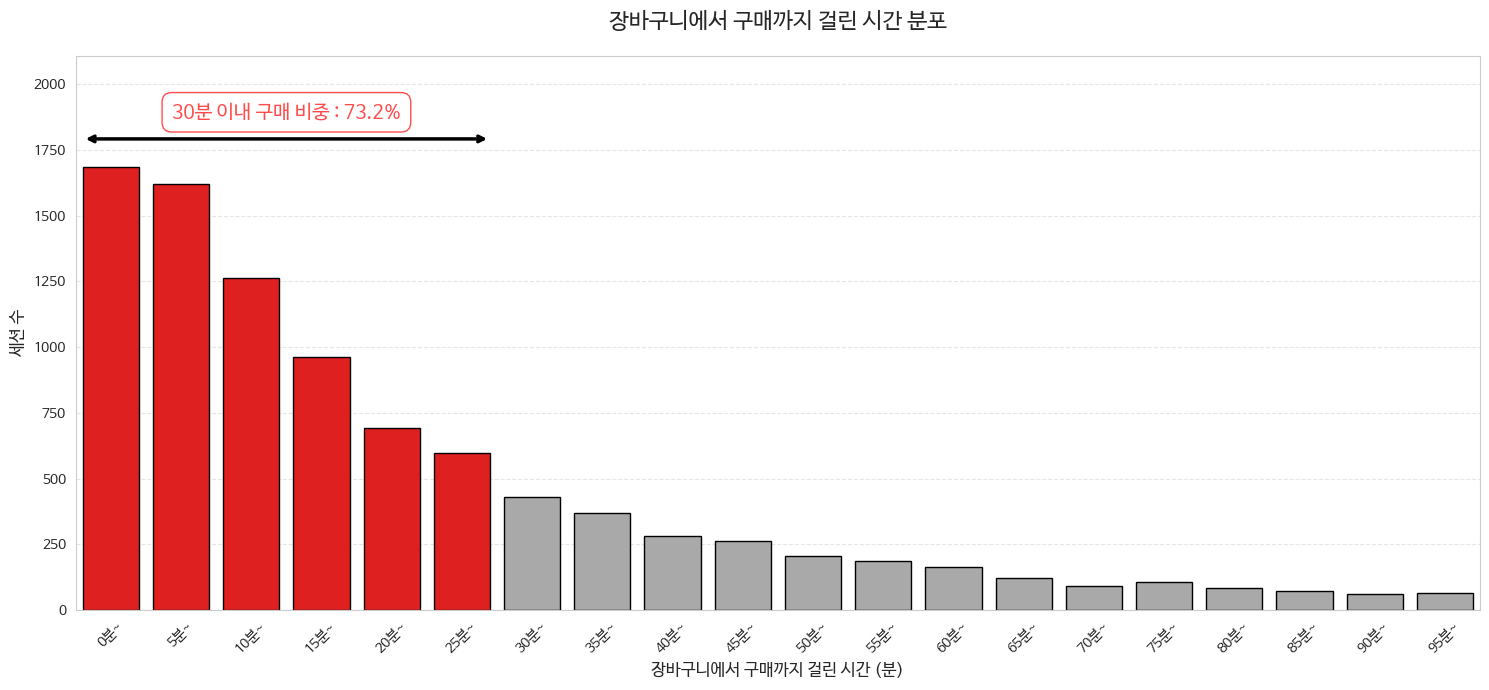

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.font_manager as fm

# 한글 폰트 강제 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 5분 단위 데이터 집계 쿼리
query_5min = """
WITH runail_events AS (
    SELECT REPLACE(event_time, ' UTC', '') AS event_time, user_session, event_type
    FROM events_2020_01 WHERE brand = 'runail'
    UNION ALL
    SELECT REPLACE(event_time, ' UTC', '') AS event_time, user_session, event_type
    FROM events_2020_02 WHERE brand = 'runail'
),
first_cart_purchase AS (
    SELECT fc.user_session,
           (STRFTIME('%s', fp.first_purchase_time) - STRFTIME('%s', fc.first_cart_time)) / 60.0 AS diff_min
    FROM (SELECT user_session, MIN(event_time) AS first_cart_time FROM runail_events WHERE event_type = 'cart' GROUP BY user_session) fc
    JOIN (SELECT user_session, MIN(event_time) AS first_purchase_time FROM runail_events WHERE event_type = 'purchase' GROUP BY user_session) fp
      ON fc.user_session = fp.user_session
    WHERE fp.first_purchase_time >= fc.first_cart_time
)
SELECT CAST(diff_min / 5 AS INTEGER) * 5 AS interval_start,
       COUNT(*) AS session_count
FROM first_cart_purchase
GROUP BY interval_start
ORDER BY interval_start ASC
LIMIT 20;
"""

df_5min = run_query(query_5min)
df_5min['time_range'] = df_5min['interval_start'].astype(str) + '분~'

# 30분 이내 누적 비율 계산 (73.16%) - Keep original calculation, only update text
within_30min_pct = 73.16

# Y축 높이 설정
max_y = df_5min['session_count'].max() * 1.25

# 시각화 설정
fig, ax = plt.subplots(figsize=(15, 7))

# 색상 로직: 쨍한 빨간색(#FF0000) 유지
def get_user_request_color(interval):
    if interval < 30:
        return '#FF0000'
    else:
        return '#A9A9A9'

custom_colors = [get_user_request_color(x) for x in df_5min['interval_start']]

sns.barplot(data=df_5min, x='time_range', y='session_count', palette=custom_colors, hue='time_range', ax=ax, legend=False, edgecolor='black', alpha=1.0)

# 화살표 길이를 막대의 양 끝에 닿도록 조정 (x축 인덱스 0번부터 5번 막대까지이므로 -0.4 ~ 5.4)
ax.annotate('', xy=(-0.4, max_y*0.85), xytext=(5.4, max_y*0.85),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2.5))

# 텍스트 박스 색상을 조금 덜 빨간색(#FF4D4D)으로 변경
ax.text(2.5, max_y*0.88, f'30분 이내 구매 비중 : {within_30min_pct:.1f}%', # Translate text
        ha='center', va='bottom', fontsize=14, fontweight='bold', color='#FF4D4D',
        bbox=dict(facecolor='white', alpha=1.0, edgecolor='#FF4D4D', boxstyle='round,pad=0.5'))

ax.set_title('장바구니에서 구매까지 걸린 시간 분포', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('장바구니에서 구매까지 걸린 시간 (분)', fontsize=12)
ax.set_ylabel('세션 수', fontsize=12)
plt.tick_params(axis='x', rotation=45)
ax.set_ylim(0, max_y)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# 장바구니 담기 후 구매까지 걸린 시간 데이터(df_5min)를 활용하여 누적 비율 계산
# df_5min은 이미 5분 단위로 집계된 데이터를 가지고 있습니다.

# 전체 세션 수 합계
total_sessions = df_5min['session_count'].sum()

# 20분 이내 (interval_start < 20 구간의 합: 0, 5, 10, 15분 구간)
within_20min_count = df_5min[df_5min['interval_start'] < 20]['session_count'].sum()
within_20min_pct = (within_20min_count / total_sessions) * 100

# 30분 이내 (interval_start < 30 구간의 합: 0~25분 구간)
within_30min_count = df_5min[df_5min['interval_start'] < 30]['session_count'].sum()
within_30min_pct = (within_30min_count / total_sessions) * 100

print(f"[Runail 구매 전환 시간 분석]")
print(f"- 20분 이내 구매 완료 비율: {within_20min_pct:.2f}%")
print(f"- 30분 이내 구매 완료 비율: {within_30min_pct:.2f}%")

# 시각적 확인을 위한 간단한 데이터프레임
pct_summary = pd.DataFrame({
    '구간': ['20분 이내', '30분 이내'],
    '누적 비율 (%)': [within_20min_pct, within_30min_pct]
})
display(pct_summary)

[Runail 구매 전환 시간 분석]
- 20분 이내 구매 완료 비율: 59.36%
- 30분 이내 구매 완료 비율: 73.16%


,구간,누적 비율 (%)
0,20분 이내,59.358576
1,30분 이내,73.163145


E: Invalid operation quiet


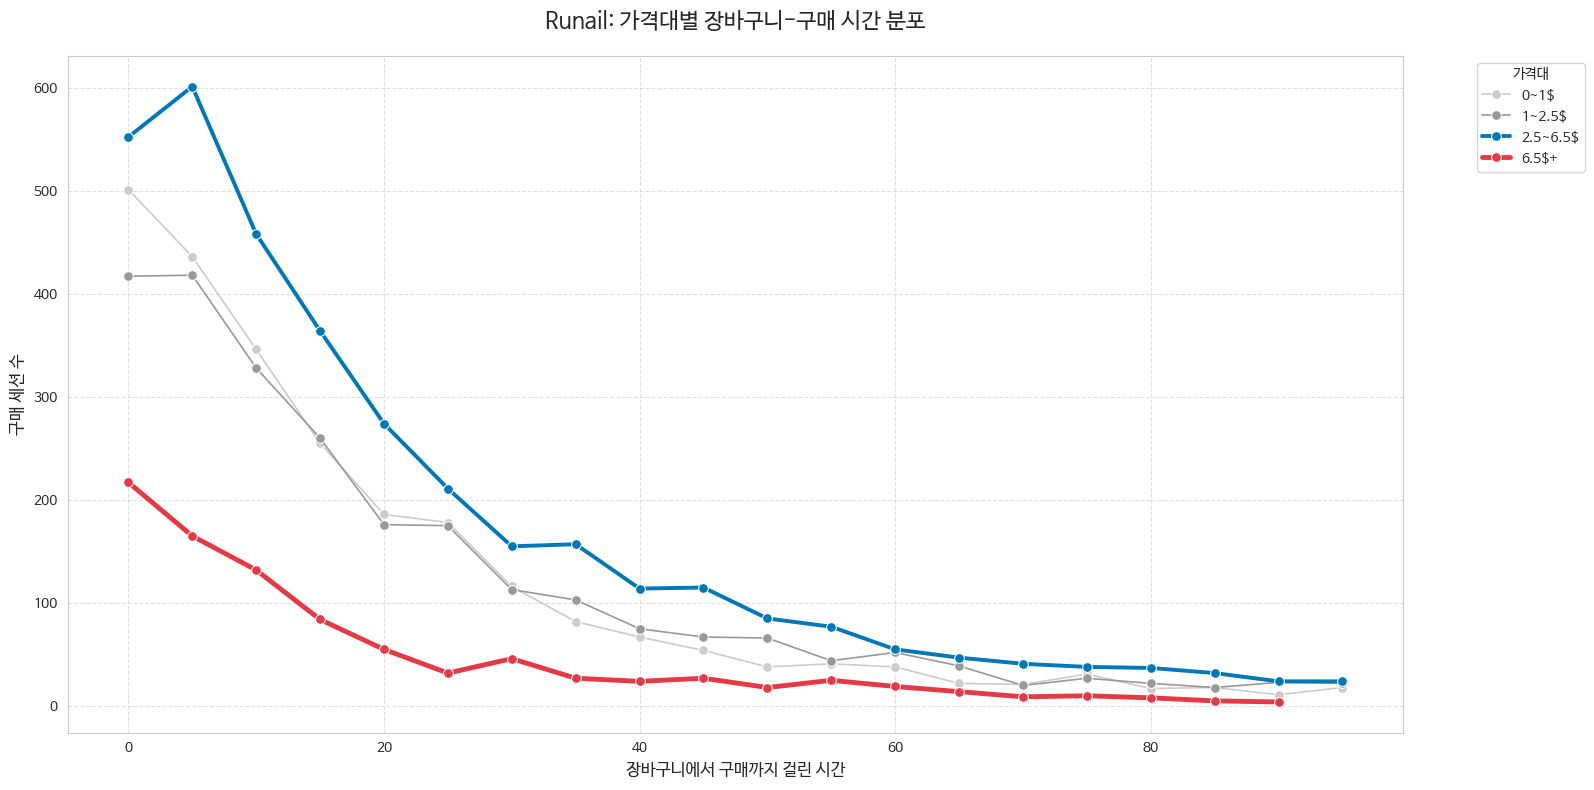

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. 나눔 폰트 설치 (Colab/Linux 환경)
!apt-get quiet install -y fonts-nanum

# 2. Matplotlib 메모리에 폰트 파일(.ttf) 강제 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)

# 3. Seaborn 스타일 설정
sns.set_style("whitegrid")

# 4. 폰트 설정 적용
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 쿼리 및 데이터 로드 (라벨명 2.5~6.5$ 로 변경)
# ==========================================
query_time_dist_by_price = """
WITH runail_events AS (
    SELECT REPLACE(event_time, ' UTC', '') AS event_time, user_session, event_type, price
    FROM events_2020_01 WHERE brand = 'runail'
    UNION ALL
    SELECT REPLACE(event_time, ' UTC', '') AS event_time, user_session, event_type, price
    FROM events_2020_02 WHERE brand = 'runail'
),
first_cart_purchase AS (
    SELECT
        fc.user_session, fc.price,
        CASE
            WHEN fc.price < 1 THEN '0~1$'
            WHEN fc.price < 2.5 THEN '1~2.5$'
            WHEN fc.price < 6.5 THEN '2.5~6.5$'
            ELSE '6.5$+'
        END AS price_range,
        (STRFTIME('%s', fp.first_purchase_time) - STRFTIME('%s', fc.first_cart_time)) / 60.0 AS diff_min
    FROM (SELECT user_session, price, MIN(event_time) AS first_cart_time FROM runail_events WHERE event_type = 'cart' GROUP BY user_session) fc
    JOIN (SELECT user_session, MIN(event_time) AS first_purchase_time FROM runail_events WHERE event_type = 'purchase' GROUP BY user_session) fp
      ON fc.user_session = fp.user_session
    WHERE fp.first_purchase_time >= fc.first_cart_time
)
SELECT
    price_range,
    CAST(diff_min / 5 AS INTEGER) * 5 AS interval_start,
    COUNT(*) AS session_count
FROM first_cart_purchase
WHERE diff_min <= 100
GROUP BY price_range, interval_start
ORDER BY
    CASE
        WHEN price_range = '0~1$' THEN 1
        WHEN price_range = '1~2.5$' THEN 2
        WHEN price_range = '2.5~6.5$' THEN 3
        ELSE 4
    END,
    interval_start ASC;
"""

df_time_price = run_query(query_time_dist_by_price)

# ==========================================
# 시각화 실행 (2.5~6.5$ 및 6.5$+ 시각적 강조)
# ==========================================
plt.figure(figsize=(16, 8))

# 1. 커스텀 팔레트: 2.5~6.5$ 는 선명한 로열블루, 6.5$+ 는 강렬한 레드, 하위 구간은 회색
custom_palette = {
    '0~1$': '#CCCCCC',      # 연한 회색
    '1~2.5$': '#999999',    # 중간 회색
    '2.5~6.5$': '#0077B6',  # 선명한 블루 (눈에 잘 띄게 강조)
    '6.5$+': '#E63946'      # 선명한 레드 (최고가 구간 강조)
}

# 2. 커스텀 선 두께
custom_sizes = {
    '0~1$': 1.2,
    '1~2.5$': 1.2,
    '2.5~6.5$': 2.8,  # 시각적으로 또렷하게 두께 부여
    '6.5$+': 3.5
}

ax = sns.lineplot(
    data=df_time_price,
    x='interval_start',
    y='session_count',
    hue='price_range',
    size='price_range',
    sizes=custom_sizes,
    palette=custom_palette,
    marker='o',
    markersize=7
)

plt.title('Runail: 가격대별 장바구니-구매 시간 분포', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('장바구니에서 구매까지 걸린 시간', fontsize=12)
plt.ylabel('구매 세션 수', fontsize=12)
plt.legend(title='가격대', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

E: Invalid operation quiet


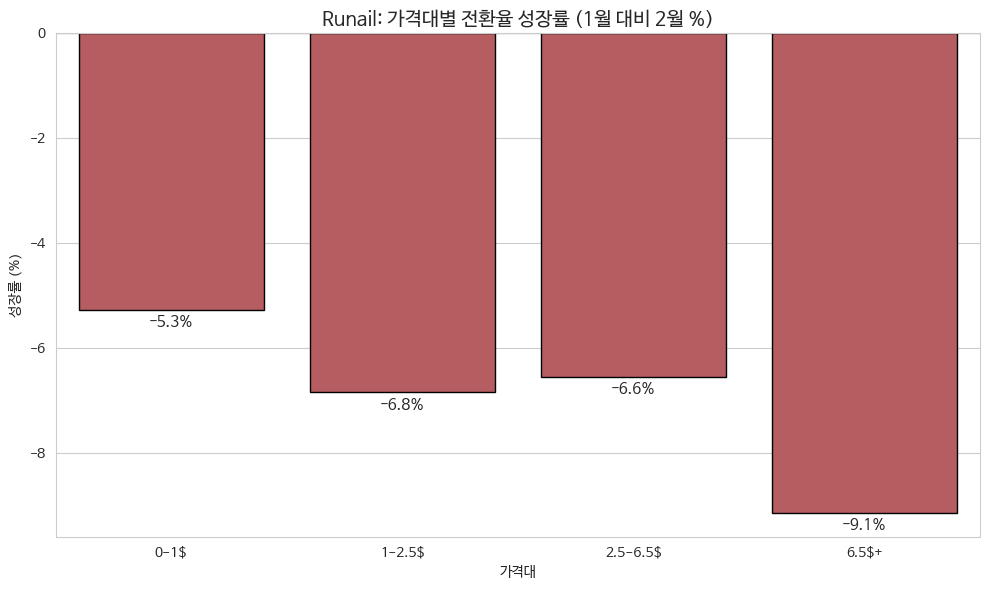

,price_range,jan_conv_rate,feb_conv_rate,growth_rate
0,0-1$,16.333262,15.471734,-5.274682
1,1-2.5$,13.372645,12.456918,-6.847762
2,2.5-6.5$,8.903936,8.320251,-6.555352
3,6.5$+,4.495469,4.084455,-9.142834


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import platform

# 1. 나눔 폰트 설치 (Colab/Linux 환경)
!apt-get quiet install -y fonts-nanum

# 2. Matplotlib 메모리에 폰트 파일(.ttf) 직접 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)

# 3. Seaborn 스타일 설정 (폰트 설정보다 먼저 선언되어야 초기화되지 않습니다)
sns.set_style("whitegrid")

# 4. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'     # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic')       # 리눅스/코랩

# 마이너스 폰트 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 가격대별 1월 대비 2월 구매 전환율 변화율 분석 SQL
query_price_conv_growth = """
WITH monthly_data AS (
    SELECT '2020-01' AS month, price, user_session, event_type FROM events_2020_01 WHERE brand = 'runail'
    UNION ALL
    SELECT '2020-02' AS month, price, user_session, event_type FROM events_2020_02 WHERE brand = 'runail'
),
segmented_data AS (
    SELECT
        month,
        user_session,
        event_type,
        CASE
            WHEN price < 1 THEN '0-1$'
            WHEN price < 2.5 THEN '1-2.5$'
            WHEN price < 6.5 THEN '2.5-6.5$'
            ELSE '6.5$+'
        END AS price_range
    FROM monthly_data
),
metrics AS (
    SELECT
        month,
        price_range,
        COUNT(DISTINCT user_session) AS total_sessions,
        COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_session END) AS purchase_sessions
    FROM segmented_data
    GROUP BY month, price_range
),
pivot_conv AS (
    SELECT
        price_range,
        MAX(CASE WHEN month = '2020-01' THEN CAST(purchase_sessions AS REAL) / total_sessions * 100 END) AS jan_conv_rate,
        MAX(CASE WHEN month = '2020-02' THEN CAST(purchase_sessions AS REAL) / total_sessions * 100 END) AS feb_conv_rate
    FROM metrics
    GROUP BY price_range
)
SELECT
    price_range,
    jan_conv_rate,
    feb_conv_rate,
    ((feb_conv_rate - jan_conv_rate) / jan_conv_rate) * 100 AS growth_rate
FROM pivot_conv
ORDER BY
    CASE
        WHEN price_range = '0-1$' THEN 1
        WHEN price_range = '1-2.5$' THEN 2
        WHEN price_range = '2.5-6.5$' THEN 3
        ELSE 4
    END;
"""

df_price_conv_growth = run_query(query_price_conv_growth)

# 시각화
plt.figure(figsize=(10, 6))

colors = ['#4C72B0' if x >= 0 else '#C44E52' for x in df_price_conv_growth['growth_rate']]

ax = sns.barplot(x='price_range', y='growth_rate', data=df_price_conv_growth, palette=colors, hue='price_range', legend=False, edgecolor='black')

plt.title('Runail: 가격대별 전환율 성장률 (1월 대비 2월 %)', fontsize=14, fontweight='bold')
plt.ylabel('성장률 (%)')
plt.xlabel('가격대')
plt.axhline(0, color='black', linewidth=0.8)

# 수치 표시 (xytext 오프셋을 조정하여 막대에 더 가깝게 배치)
for p in ax.patches:
    height = p.get_height()
    va_dir = 'bottom' if height > 0 else 'top'
    # 양수일 때는 위로 3pt, 음수일 때는 아래로 3pt만 띄움
    offset = 3 if height > 0 else -3

    ax.annotate(f'{height:+.1f}%', (p.get_x() + p.get_width() / 2., height),
                ha='center', va=va_dir, fontsize=11, fontweight='bold',
                xytext=(0, offset), textcoords='offset points')

plt.tight_layout()
plt.show()

display(df_price_conv_growth)